# Understanding ROC Curves and AUC in Machine Learning
## A Beginner-Friendly but Technically Detailed Teaching Notebook

---

**Dataset:** Pima Indians Diabetes (768 samples, 8 features, binary outcome)  
**Models:** Logistic Regression · Random Forest · Gradient Boosting  
**Core Focus:** Deep conceptual understanding of ROC curves and AUC — not peak performance

---

### What You Will Learn

By the end of this notebook you will be able to:

1. **Explain** what True Positive Rate, False Positive Rate, and Specificity mean — using both words and formulas
2. **Understand** how a classification threshold works and what happens when you change it
3. **Read and interpret** an ROC curve — including what a "perfect", "good", "random", and "bad" curve look like
4. **Calculate and compare** AUC scores across multiple models
5. **Tune a threshold** to optimise for a specific clinical or business goal
6. **Recognise** situations where ROC/AUC can be misleading

---

### Notebook Structure

| Section | Topic |
|---------|-------|
| **Part 1** | Conceptual foundation — confusion matrix, TPR, FPR, Specificity |
| **Part 2** | Classification thresholds — what they are and why they matter |
| **Part 3** | ROC curves — construction, reading, interpretation |
| **Part 4** | AUC — meaning, range, good vs bad values |
| **Part 5** | Dataset loading and exploratory data analysis |
| **Part 6** | Data preprocessing |
| **Part 7** | Model training (3 models of increasing complexity) |
| **Part 8** | Probability predictions and threshold demonstrations |
| **Part 9** | ROC curves for all models on one plot |
| **Part 10** | Threshold tuning — optimising TPR/FPR trade-off |
| **Part 11** | Confusion matrices and full classification reports |
| **Part 12** | Precision-Recall curves (bonus) |
| **Part 13** | When ROC/AUC can be misleading |
| **Part 14** | Summary and key takeaways |

---
## Part 1: The Conceptual Foundation

### What Is Binary Classification?

**Binary classification** is any machine learning task where the answer is one of exactly **two categories**:

| Problem | Negative Class (0) | Positive Class (1) |
|---------|-------------------|-------------------|
| Diabetes screening | No diabetes | Has diabetes |
| Spam detection | Not spam | Spam |
| Fraud detection | Legitimate transaction | Fraudulent transaction |
| Medical imaging | No tumour | Tumour present |

A trained classifier takes in features (glucose level, BMI, age, etc.) and outputs a **predicted probability** that the sample belongs to the positive class. For example: `0.83` means "83% chance this person has diabetes."

We then apply a **threshold** (by default 0.5) to convert that probability into a hard label:
- Probability ≥ 0.5 → predict **1** (positive)
- Probability < 0.5 → predict **0** (negative)

---

### The Confusion Matrix — The Building Block of All Evaluation Metrics

Once we have predictions, we compare them to the true labels and categorise every prediction into one of **four buckets**:

```
                        PREDICTED
                    Negative (0)  |  Positive (1)
                ────────────────────────────────────
ACTUAL  Negative (0) │  True Negative (TN)  │  False Positive (FP)  │
        Positive (1) │  False Negative (FN)  │  True Positive (TP)   │
                ────────────────────────────────────
```

**Meaning of each cell (in a diabetes context):**

| Cell | Meaning |
|------|---------|
| **TP — True Positive** | Person **has** diabetes; model predicted **diabetes**. ✅ Correct |
| **TN — True Negative** | Person does **not** have diabetes; model predicted **no diabetes**. ✅ Correct |
| **FP — False Positive** | Person does **not** have diabetes; model predicted **diabetes**. ❌ Wrong (Type I error) |
| **FN — False Negative** | Person **has** diabetes; model predicted **no diabetes**. ❌ Wrong (Type II error) |

> 💡 **Intuition:** In medicine, a False Negative (missed diagnosis) is usually more dangerous than a False Positive (unnecessary follow-up). This drives us to tune our models differently depending on the stakes.

---

### The Five Key Metrics Derived from the Confusion Matrix

From just TP, TN, FP, and FN we can derive every important classification metric:

#### 1. Accuracy
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

What fraction of ALL predictions were correct? Simple, but misleading when classes are imbalanced.

#### 2. True Positive Rate (TPR) = Recall = Sensitivity
$$\text{TPR} = \frac{TP}{TP + FN}$$

Of all **actual positives**, what fraction did we **correctly identify**? This is the y-axis of the ROC curve.
A high TPR means we catch most of the real cases (low miss rate).

#### 3. False Positive Rate (FPR)
$$\text{FPR} = \frac{FP}{FP + TN}$$

Of all **actual negatives**, what fraction did we **incorrectly flag as positive**? This is the x-axis of the ROC curve.
A low FPR means we have few false alarms.

#### 4. Specificity = True Negative Rate (TNR)
$$\text{Specificity} = \frac{TN}{TN + FP} = 1 - \text{FPR}$$

Of all **actual negatives**, what fraction did we **correctly identify**?
Specificity and FPR are exact inverses — maximising Specificity means minimising FPR.

#### 5. Precision = Positive Predictive Value (PPV)
$$\text{Precision} = \frac{TP}{TP + FP}$$

Of all **predicted positives**, what fraction were **truly positive**?

> 🧠 **Memory trick:** Recall asks "did we find all the sick people?", Precision asks "when we said someone is sick, were we right?"

---
## Part 2: Classification Thresholds — The Hidden Lever

### What Is a Classification Threshold?

Every classification model produces a **probability score**, not directly a class label.
For example, scikit-learn's `predict_proba()` returns something like:

```
Sample 1: [0.78, 0.22]  → 78% chance of class 0 (no diabetes), 22% chance of class 1 (diabetes)
Sample 2: [0.11, 0.89]  → 11% chance of class 0,  89% chance of class 1 (diabetes)
Sample 3: [0.52, 0.48]  → 52% chance of class 0,  48% chance of class 1 (diabetes — borderline!)
```

The **threshold** is the cutoff probability above which we declare the prediction **positive (1)**:

- Default threshold = **0.5** (most frameworks use this automatically)
- Custom threshold = **any value between 0 and 1**

### What Happens When You Change the Threshold?

This is the most important intuition to understand:

```
Low threshold (e.g., 0.2):   More predictions are Positive → High TPR, but also High FPR
High threshold (e.g., 0.8):  More predictions are Negative → Low FPR, but also Low TPR
```

**Diabetes example:**

| Threshold | Effect | When to Use |
|-----------|--------|-------------|
| **0.2 (low)** | Almost everyone flagged as diabetic. Catch nearly all real cases but many false alarms. | Mass screening where missing a case is catastrophic |
| **0.5 (default)** | Balanced approach. Standard behaviour. | General purpose |
| **0.8 (high)** | Only predict diabetes when very confident. Few false alarms but miss many real cases. | When treatment has serious side effects |

> 🔑 **Key insight:** The ROC curve is built by sweeping the threshold from 0 to 1 and recording TPR and FPR at every step. It is a **complete picture of all possible threshold choices** — not just the default 0.5.

### Why Not Just Use Accuracy?

Suppose 90% of people in a dataset do NOT have diabetes. A model that **always predicts "no diabetes"** would have:
- Accuracy: **90%** ✨ (looks great!)
- TPR (Recall): **0.0** 💀 (catches ZERO actual diabetics)

Accuracy is blind to class imbalance. ROC curves and AUC reveal the full truth.

---
## Part 3: ROC Curves — What They Are and How to Read Them

### Constructing an ROC Curve (Step by Step)

An ROC (Receiver Operating Characteristic) curve is a **graph** that shows the performance of a classification model across **all possible thresholds**:

- **X-axis:** False Positive Rate (FPR) — ranges from 0 to 1
- **Y-axis:** True Positive Rate (TPR) — ranges from 0 to 1

**Algorithm to build it:**
1. Get the model's probability scores for all test samples
2. Sort samples by probability (highest to lowest)
3. For each unique score, set it as the threshold
4. Calculate TPR and FPR at that threshold
5. Plot the point (FPR, TPR)
6. Connect all points → ROC curve

### Interpreting the ROC Curve Shape

```
TPR
1.0  ┤  ★ Perfect Classifier         
     │ ╱│                            
0.8  ┤╱ │  ╭──────── Excellent (AUC ≈ 0.95)
     │   │ ╱                         
0.6  ┤   │╱  ─── Good (AUC ≈ 0.80)  
     │   ╱                           
0.4  ┤  ╱╲─── Random (AUC = 0.50)  
     │ ╱                             
0.2  ┤╱                              
     │                               
0.0  └─────────────────────── FPR
     0.0  0.2  0.4  0.6  0.8  1.0  
```

| Curve Shape | Interpretation |
|-------------|----------------|
| **Hugs the top-left corner** | Excellent model — high TPR with low FPR |
| **Near the diagonal line** | Random guessing — no discrimination ability |
| **Below the diagonal** | Worse than random — model may have inverted labels |
| **Single dot at (0, 1)** | Perfect classifier (theoretical) |

### Three Reference Points to Always Remember

- **(0, 0):** Threshold = 1.0. Model predicts everything as Negative. TPR=0, FPR=0.
- **(1, 1):** Threshold = 0.0. Model predicts everything as Positive. TPR=1, FPR=1.
- **(0, 1):** Perfect classifier — catches ALL positives with ZERO false alarms.

Moving along the ROC curve from (0,0) to (1,1) corresponds to **lowering the threshold** from 1 to 0.

---
## Part 4: AUC — Area Under the ROC Curve

### What Is AUC?

AUC stands for **Area Under the (ROC) Curve**. It is a **single number** that summarises the entire ROC curve:

$$\text{AUC} = \int_0^1 \text{TPR}(t) \, d(\text{FPR}(t))$$

In practice, it is computed numerically using the **trapezoidal rule** over the discrete (FPR, TPR) points.

### Probabilistic Interpretation (Very Important!)

> **AUC = the probability that a randomly chosen positive sample will be ranked higher (given a higher score) than a randomly chosen negative sample.**

For a diabetes model with AUC = 0.85:
> "If I pick one person **with** diabetes and one person **without** diabetes at random, there is an **85% chance** that the model assigns the diabetic person a higher probability score."

This interpretation makes AUC scale-invariant and threshold-invariant.

### AUC Reference Guide

| AUC Score | Interpretation | Analogy |
|-----------|---------------|---------|
| **1.00** | Perfect model | Never makes a mistake |
| **0.90 – 0.99** | Excellent | Expert-level |
| **0.80 – 0.89** | Good | Very useful |
| **0.70 – 0.79** | Fair | Usable but limited |
| **0.60 – 0.69** | Poor | Marginal benefit |
| **0.50** | Random guessing | Coin flip |
| **< 0.50** | Worse than random | Labels may be inverted |

> 💡 For most clinical applications (e.g., disease screening), AUC > 0.80 is considered acceptable.

### Key Properties of AUC

1. **Threshold-independent:** Measures overall discrimination regardless of any specific cutoff
2. **Scale-invariant:** Only cares about ranking, not absolute probabilities
3. **Symmetric:** AUC of 0.3 is as informative as 0.7 (just use inverted predictions)
4. **Comparable across models:** Makes it easy to rank models head-to-head

---
## Part 5: Setup and Dataset

### Library Requirements

This notebook requires the following Python packages:
- `numpy`, `pandas` — data manipulation
- `matplotlib`, `seaborn` — visualisation
- `scikit-learn` — ML models, metrics, preprocessing
- `xgboost` — optional; we fall back to `GradientBoostingClassifier` if not installed

Run the next cell to install any missing packages, then the setup cell to import everything.

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Install missing packages (safe to re-run)
# ─────────────────────────────────────────────────────────────────────────────
import subprocess
import sys

def install(package):
    """Install a package using pip if it is not already installed."""
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", package])

required_packages = ["scikit-learn", "xgboost", "seaborn", "matplotlib", "pandas", "numpy"]

for pkg in required_packages:
    try:
        __import__(pkg.replace("-", "_").split(".")[0])
        print(f"  ✓ {pkg} already installed")
    except ImportError:
        print(f"  Installing {pkg}...")
        install(pkg)
        print(f"  ✓ {pkg} installed successfully")

print("\nAll required packages are ready!")

  Installing scikit-learn...
  ✓ scikit-learn installed successfully
  ✓ xgboost already installed
  ✓ seaborn already installed
  ✓ matplotlib already installed
  ✓ pandas already installed
  ✓ numpy already installed

All required packages are ready!


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Import all libraries and configure notebook settings
# ─────────────────────────────────────────────────────────────────────────────

# ── Standard library
import warnings
warnings.filterwarnings("ignore")

# ── Numerical computing
import numpy as np

# ── Data manipulation
import pandas as pd

# ── Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Scikit-learn: data utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Scikit-learn: models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ── Scikit-learn: evaluation metrics
from sklearn.metrics import (
    roc_curve,
    auc,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

# ── XGBoost (optional; falls back to GradientBoostingClassifier)
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("✓ XGBoost available — will use XGBClassifier as the advanced model.")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("✗ XGBoost not installed — will use GradientBoostingClassifier instead.")

# ── Plot styling
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
sns.set_palette("husl")

# ── Reproducibility seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("\nAll imports successful and environment configured.")

✓ XGBoost available — will use XGBClassifier as the advanced model.

All imports successful and environment configured.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Load the Pima Indians Diabetes Dataset
#
# The Pima Indians Diabetes dataset is a classic benchmark for binary
# classification. It contains medical measurements from 768 Pima Indian
# women and records whether each individual developed diabetes within
# 5 years of the measurements.
#
# Features:
#   Pregnancies               — Number of times pregnant
#   Glucose                   — Plasma glucose concentration (2-hour oral glucose test)
#   BloodPressure             — Diastolic blood pressure (mm Hg)
#   SkinThickness             — Triceps skin fold thickness (mm)
#   Insulin                   — 2-hour serum insulin (mu U/ml)
#   BMI                       — Body mass index (weight kg / height m²)
#   DiabetesPedigreeFunction  — Family history score (genetic risk proxy)
#   Age                       — Age in years
#
# Target:
#   Outcome — 0 = No diabetes, 1 = Diabetes
# ─────────────────────────────────────────────────────────────────────────────

# We try to load from the Plotly public dataset repository (requires internet).
# If offline, we generate a synthetic dataset with the same structure.

DATASET_URL = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"

try:
    df = pd.read_csv(DATASET_URL)
    print(f"✓ Dataset loaded from URL successfully.")
    print(f"  Source: Pima Indians Diabetes Dataset")
except Exception as e:
    print(f"✗ Could not fetch from URL ({e})")
    print("  Generating a synthetic dataset with matching structure and statistics...")

    # Synthetic dataset that replicates the approximate distribution of the
    # real Pima dataset — useful for offline environments.
    from sklearn.datasets import make_classification

    rng = np.random.default_rng(RANDOM_STATE)
    n = 768

    X_syn, y_syn = make_classification(
        n_samples=n,
        n_features=8,
        n_informative=5,
        n_redundant=2,
        weights=[0.651, 0.349],   # reflects real class balance (~65/35)
        random_state=RANDOM_STATE,
        flip_y=0.05,
    )

    col_names = [
        "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
        "Insulin", "BMI", "DiabetesPedigreeFunction", "Age",
    ]

    df = pd.DataFrame(X_syn, columns=col_names)
    df["Outcome"] = y_syn
    print("  ✓ Synthetic dataset created with 768 samples and 8 features.")

# ── Quick sanity check
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

✓ Dataset loaded from URL successfully.
  Source: Pima Indians Diabetes Dataset

Dataset shape: (768, 9)
Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


---
## Part 5 (continued): Exploratory Data Analysis

Before training any model, we explore the data to understand:
- The **class balance** (how many diabetic vs non-diabetic)
- The **feature distributions** (range, skewness, outliers)
- The **correlations** between features and the target

This informs both our preprocessing steps and our expectations for model performance.

DATASET OVERVIEW

Shape: 768 rows × 9 columns

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64

Null values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0

Basic statistics:

CLASS DISTRIBUTION

  No Diabetes (0):  500 samples  (65.1%)
  Diabetes    (1):  268 samples  (34.9%)

  Imbalance ratio: 1.87:1 (negative:positive)


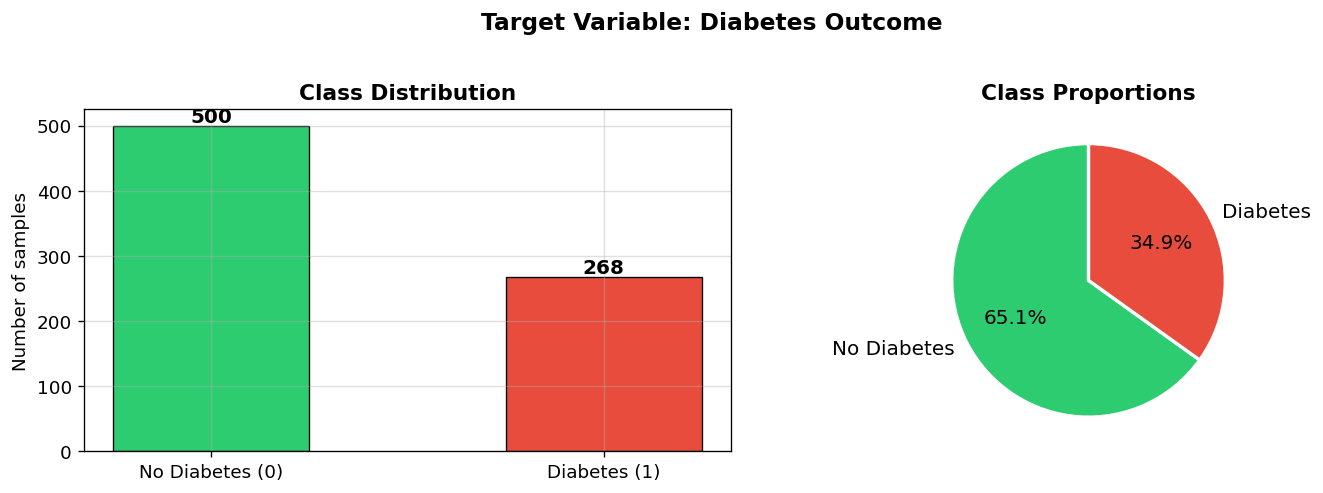


⚠️  Note: The dataset has a mild class imbalance (~65% negative, ~35% positive).
    This makes accuracy a somewhat misleading metric — we'll see why with ROC/AUC.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Dataset overview and class distribution
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nData types:\n{df.dtypes.to_string()}")
print(f"\nNull values per column:\n{df.isnull().sum().to_string()}")
print(f"\nBasic statistics:")
df.describe().round(2)

# ── Class distribution
print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)
counts = df["Outcome"].value_counts()
print(f"\n  No Diabetes (0): {counts[0]:>4} samples  ({counts[0]/len(df)*100:.1f}%)")
print(f"  Diabetes    (1): {counts[1]:>4} samples  ({counts[1]/len(df)*100:.1f}%)")
print(f"\n  Imbalance ratio: {counts[0]/counts[1]:.2f}:1 (negative:positive)")

# ── Visualise class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ["#2ecc71", "#e74c3c"]
axes[0].bar(
    ["No Diabetes (0)", "Diabetes (1)"],
    [counts[0], counts[1]],
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    width=0.5,
)
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_ylabel("Number of samples")
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold", fontsize=12)

# Pie chart
axes[1].pie(
    [counts[0], counts[1]],
    labels=["No Diabetes", "Diabetes"],
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 12},
)
axes[1].set_title("Class Proportions", fontweight="bold")

plt.suptitle("Target Variable: Diabetes Outcome", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\n⚠️  Note: The dataset has a mild class imbalance (~65% negative, ~35% positive).")
print("    This makes accuracy a somewhat misleading metric — we'll see why with ROC/AUC.")

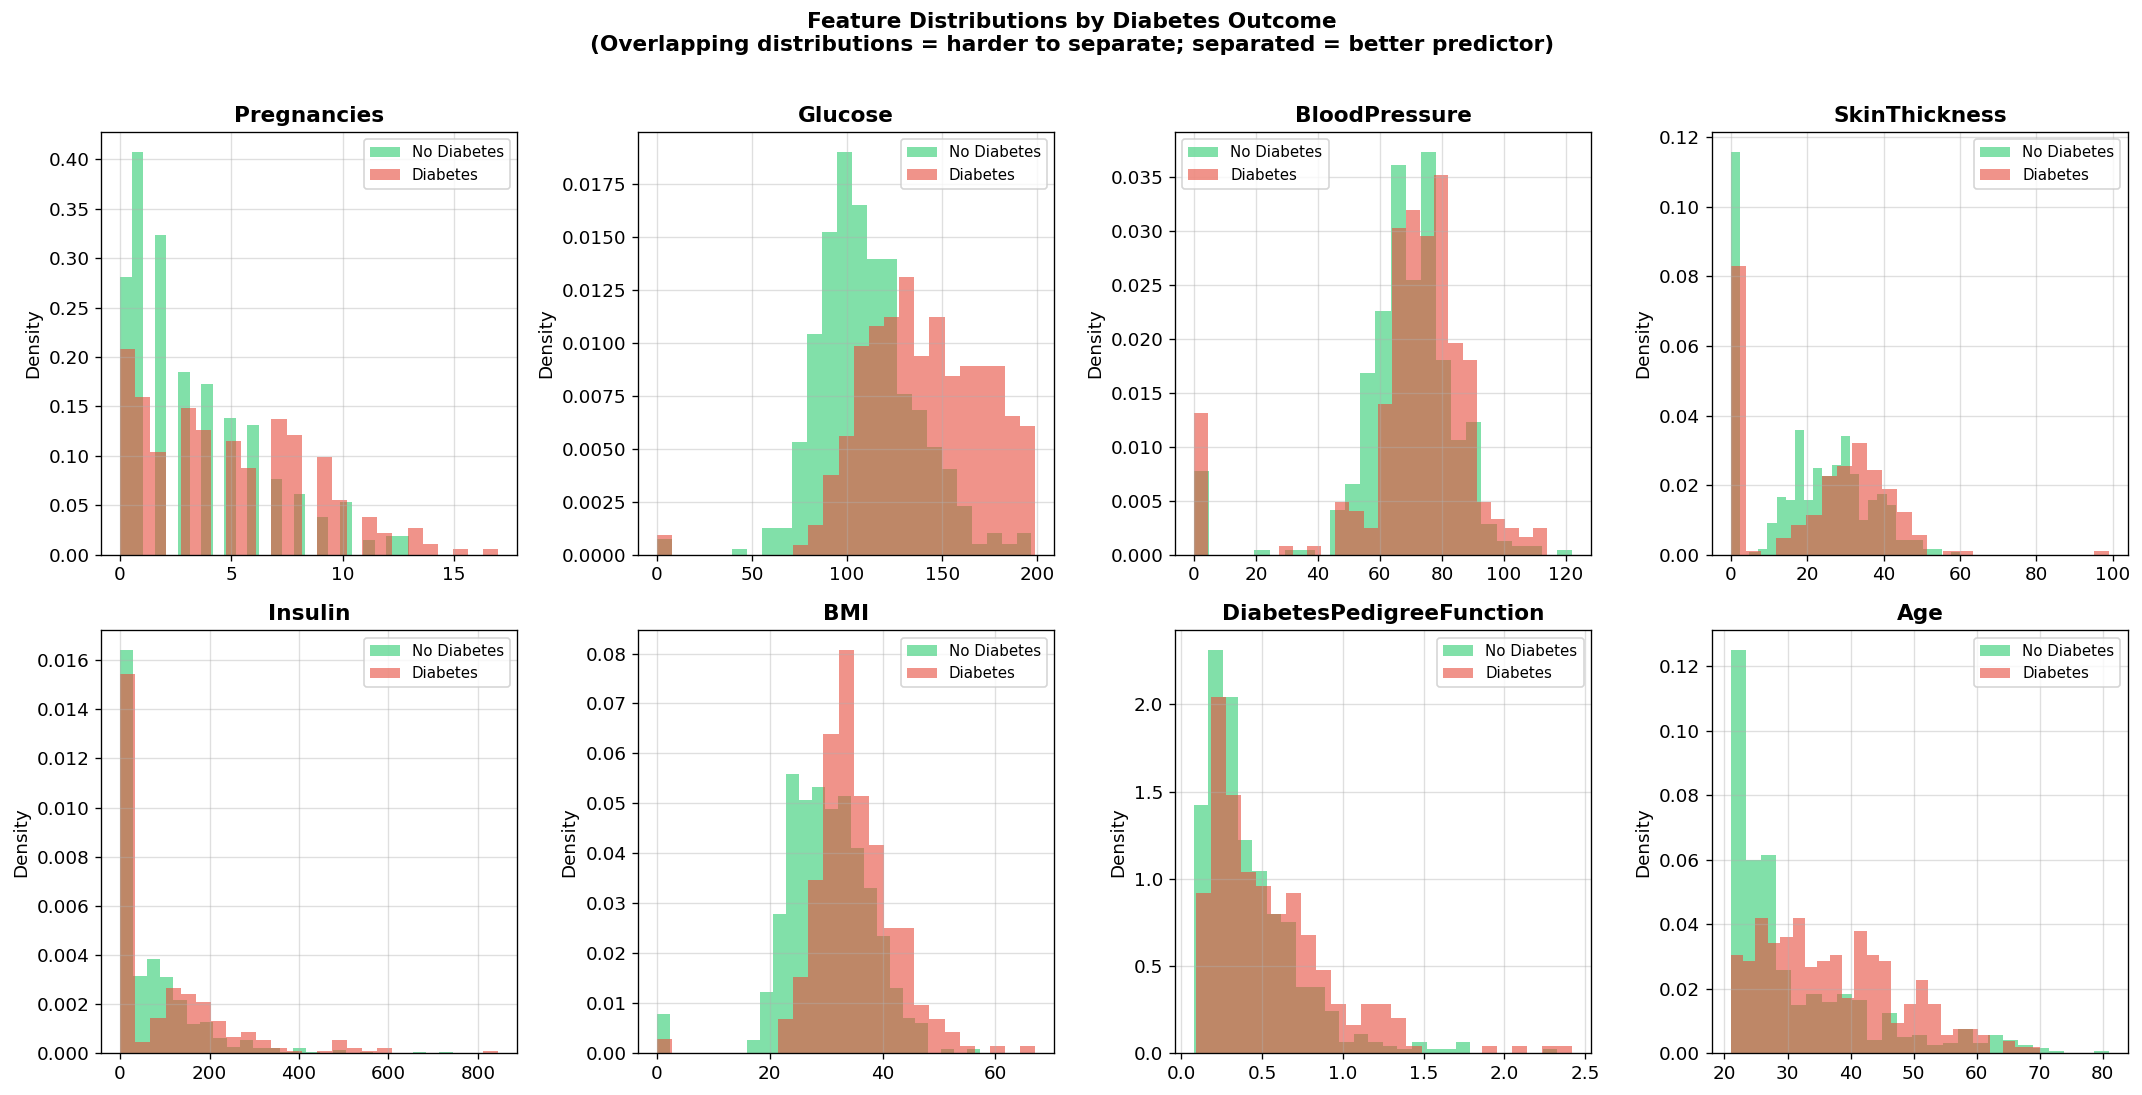

Most discriminative features (largest mean difference between classes):
-------------------------------------------------------
  Pregnancies                     Δmean =   1.57  (no=3.3, yes=4.9)
  Glucose                         Δmean =  31.28  (no=110.0, yes=141.3)
  BloodPressure                   Δmean =   2.64  (no=68.2, yes=70.8)
  SkinThickness                   Δmean =   2.50  (no=19.7, yes=22.2)
  Insulin                         Δmean =  31.54  (no=68.8, yes=100.3)
  BMI                             Δmean =   4.84  (no=30.3, yes=35.1)
  DiabetesPedigreeFunction        Δmean =   0.12  (no=0.4, yes=0.6)
  Age                             Δmean =   5.88  (no=31.2, yes=37.1)


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Feature distributions — do diabetic and non-diabetic patients differ?
#
# For each feature, we plot the distribution split by class.
# Features that show clear separation between classes are likely
# to be strong predictors in our models.
# ─────────────────────────────────────────────────────────────────────────────

feature_cols = [c for c in df.columns if c != "Outcome"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

palette = {0: "#2ecc71", 1: "#e74c3c"}
label_map = {0: "No Diabetes", 1: "Diabetes"}

for i, feat in enumerate(feature_cols):
    ax = axes[i]
    for outcome_val in [0, 1]:
        subset = df[df["Outcome"] == outcome_val][feat]
        ax.hist(
            subset,
            bins=25,
            alpha=0.6,
            color=palette[outcome_val],
            label=label_map[outcome_val],
            edgecolor="none",
            density=True,  # use density so different-sized groups are comparable
        )
    ax.set_title(feat, fontweight="bold")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.suptitle(
    "Feature Distributions by Diabetes Outcome\n"
    "(Overlapping distributions = harder to separate; separated = better predictor)",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

# ── Highlight the most discriminative features
print("Most discriminative features (largest mean difference between classes):")
print("-" * 55)
for feat in feature_cols:
    mean_no  = df[df["Outcome"] == 0][feat].mean()
    mean_yes = df[df["Outcome"] == 1][feat].mean()
    diff = abs(mean_yes - mean_no)
    print(f"  {feat:<30}  Δmean = {diff:>6.2f}  (no={mean_no:.1f}, yes={mean_yes:.1f})")

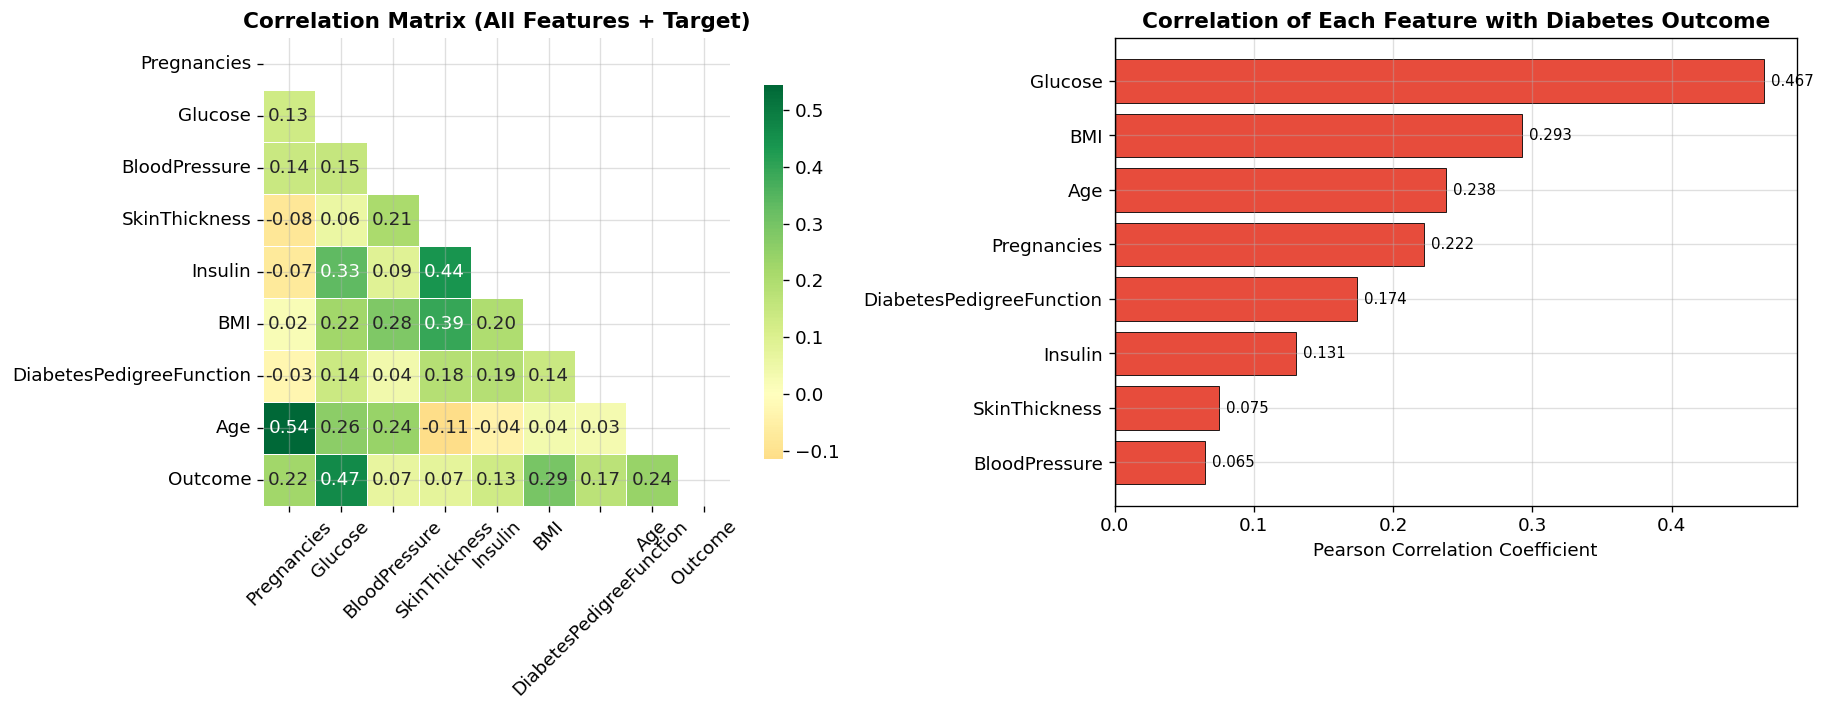


Interpretation:
  Glucose has the strongest positive correlation with Diabetes outcome.
  High correlations between features (e.g., Age-Pregnancies) suggest some redundancy.
  Even moderate correlations can be highly informative for non-linear models.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Correlation heatmap
#
# A correlation heatmap shows the linear relationships between all features
# and between features and the target.
#
# Strong correlation with Outcome → useful predictor
# Strong correlation between features → potential multicollinearity
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Heatmap of all feature correlations
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle = redundant

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=axes[0],
)
axes[0].set_title("Correlation Matrix (All Features + Target)", fontweight="bold")
axes[0].tick_params(axis="x", rotation=45)

# ── Bar chart: correlation with target only
target_corr = df.corr()["Outcome"].drop("Outcome").sort_values(ascending=True)
colors_bar = ["#e74c3c" if v > 0 else "#3498db" for v in target_corr]

axes[1].barh(target_corr.index, target_corr.values, color=colors_bar, edgecolor="black", linewidth=0.5)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlation of Each Feature with Diabetes Outcome", fontweight="bold")
axes[1].set_xlabel("Pearson Correlation Coefficient")
for i, v in enumerate(target_corr.values):
    axes[1].text(v + 0.005 if v >= 0 else v - 0.005, i, f"{v:.3f}",
                 va="center", ha="left" if v >= 0 else "right", fontsize=9)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  Glucose has the strongest positive correlation with Diabetes outcome.")
print("  High correlations between features (e.g., Age-Pregnancies) suggest some redundancy.")
print("  Even moderate correlations can be highly informative for non-linear models.")

---
## Part 6: Data Preprocessing

### What Preprocessing Do We Need?

The Pima Indians Diabetes dataset has a known issue: many physiological features
contain `0` values that are biologically impossible (e.g., Glucose = 0, BMI = 0).
These are **encoded missing values** — the data collector used 0 as a placeholder.

**Steps we will take:**
1. **Replace biologically impossible zeros** with `NaN` for the affected columns
2. **Impute** missing values with the column median (robust to outliers)
3. **Scale** features to have zero mean and unit variance — essential for Logistic Regression

> Note: Random Forest and Gradient Boosting are tree-based models and do NOT require
> feature scaling. We scale all features anyway for consistency across models.

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Data preprocessing — impute impossible zeros, then scale
# ─────────────────────────────────────────────────────────────────────────────

# ── Step 1: Separate features and target
X = df.drop("Outcome", axis=1).copy()
y = df["Outcome"].copy()

feature_cols = X.columns.tolist()

print("Step 1: Separate features and target")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
print(f"  Positive class prevalence: {y.mean()*100:.1f}%")

# ── Step 2: Replace impossible zeros with NaN
# These columns cannot physiologically be zero in a living person:
zero_impossible_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Only apply this step if these named columns exist (real dataset, not synthetic)
existing_zero_cols = [c for c in zero_impossible_cols if c in X.columns]

print(f"\nStep 2: Replace impossible zeros with NaN in {existing_zero_cols}")
zero_counts_before = {c: (X[c] == 0).sum() for c in existing_zero_cols}
for col in existing_zero_cols:
    X[col] = X[col].replace(0, np.nan)
print(f"  Zeros converted to NaN: {zero_counts_before}")

# ── Step 3: Impute NaN with column median
print("\nStep 3: Impute NaN with column median")
for col in existing_zero_cols:
    median_val = X[col].median()
    n_imputed  = X[col].isna().sum()
    X[col]     = X[col].fillna(median_val)
    if n_imputed > 0:
        print(f"  {col:<30}: imputed {n_imputed:>3} values with median={median_val:.2f}")

print("\nNo missing values remaining:", X.isnull().sum().sum() == 0)

# ── Step 4: Train / Validation / Test split (60% / 20% / 20%)
# We use three splits:
#   - Train set     (60%): used to fit all models
#   - Validation set (20%): used for threshold tuning and model selection
#   - Test set       (20%): held out entirely until final evaluation
X_temp,  X_test,  y_temp,  y_test  = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val,   y_train, y_val   = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
    # 0.25 × 0.80 = 0.20 of total → validation set is 20%
)

print("\nStep 4: Train / Validation / Test split (60 / 20 / 20)")
for name, subset_y in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"  {name:>10}: {len(subset_y):>4} samples  "
          f"(positive rate: {subset_y.mean()*100:.1f}%)")

# ── Step 5: Scale features (fit ONLY on training data to avoid data leakage)
print("\nStep 5: StandardScaler — fit on train, transform all splits")
scaler   = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_val_scaled   = scaler.transform(X_val)          # transform only
X_test_scaled  = scaler.transform(X_test)         # transform only

# Convert back to DataFrames with feature names (for readability)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_val_scaled   = pd.DataFrame(X_val_scaled,   columns=feature_cols)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_cols)

print("\n✓ Preprocessing complete!")
print("  IMPORTANT: The scaler was ONLY fit on training data.")
print("  Fitting on the full dataset would be 'data leakage' — the test set")
print("  would indirectly influence the model, giving artificially optimistic results.")

Step 1: Separate features and target
  X shape: (768, 8)
  y shape: (768,)
  Positive class prevalence: 34.9%

Step 2: Replace impossible zeros with NaN in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
  Zeros converted to NaN: {'Glucose': np.int64(5), 'BloodPressure': np.int64(35), 'SkinThickness': np.int64(227), 'Insulin': np.int64(374), 'BMI': np.int64(11)}

Step 3: Impute NaN with column median
  Glucose                       : imputed   5 values with median=117.00
  BloodPressure                 : imputed  35 values with median=72.00
  SkinThickness                 : imputed 227 values with median=29.00
  Insulin                       : imputed 374 values with median=125.00
  BMI                           : imputed  11 values with median=32.30

No missing values remaining: True

Step 4: Train / Validation / Test split (60 / 20 / 20)
       Train:  460 samples  (positive rate: 34.8%)
  Validation:  154 samples  (positive rate: 35.1%)
        Test:  154 samples  (p

---
## Part 7: Model Training

We train **three models** of increasing complexity:

| # | Model | Type | Hyperparameters |
|---|-------|------|-----------------|
| 1 | **Logistic Regression** | Linear classifier | Default (C=1.0, max_iter=1000) |
| 2 | **Random Forest** | Ensemble of decision trees | 200 trees, max_depth=10 |
| 3 | **Gradient Boosting / XGBoost** | Boosted ensemble | 200 rounds, moderate regularisation |

### Why These Three?

- **Logistic Regression** is the simplest probabilistic classifier. It assumes a linear relationship between features and log-odds. Its output probabilities are well-calibrated, making it an excellent baseline.
- **Random Forest** is a non-linear ensemble that captures feature interactions and is robust to overfitting via averaging. It tends to produce slightly less calibrated probabilities than LR.
- **XGBoost / Gradient Boosting** is a state-of-the-art gradient boosted trees model. It typically achieves the best performance on tabular data but is more prone to overfitting on small datasets without tuning.

> **Goal:** We train quickly with reasonable defaults. The focus is understanding ROC/AUC, not hyperparameter optimisation.

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Model 1 — Logistic Regression (simple linear baseline)
#
# LogisticRegression in scikit-learn minimises the log-loss (cross-entropy):
#
#   L(θ) = -Σ [ yᵢ log(p̂ᵢ) + (1-yᵢ) log(1-p̂ᵢ) ]
#
# The decision boundary is a hyperplane:
#   log(p/(1-p)) = θ₀ + θ₁x₁ + θ₂x₂ + ... + θₙxₙ
#
# Calling predict_proba() returns the probability that each sample
# belongs to class 1 (diabetes) — this is what we use for ROC curves.
# ─────────────────────────────────────────────────────────────────────────────

print("Training Model 1: Logistic Regression...")
print("-" * 50)

lr_model = LogisticRegression(
    C=1.0,              # Inverse regularisation strength; smaller = stronger regularisation
    max_iter=1000,      # Maximum iterations for optimiser convergence
    solver="lbfgs",     # Efficient solver for small-to-medium datasets
    random_state=RANDOM_STATE,
    class_weight=None,  # We use raw class weights; can set to 'balanced' for imbalanced data
)
lr_model.fit(X_train_scaled, y_train)

# ── Training and validation accuracy (a quick sanity check)
print(f"  Train Accuracy:      {lr_model.score(X_train_scaled, y_train):.4f}")
print(f"  Validation Accuracy: {lr_model.score(X_val_scaled,   y_val):.4f}")

# ── The model learned a coefficient (weight) for each feature
print("\n  Learned feature coefficients (larger |value| = more influence):")
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": lr_model.coef_[0],
    "|Coefficient|": np.abs(lr_model.coef_[0]),
}).sort_values("|Coefficient|", ascending=False)

for _, row in coef_df.iterrows():
    direction = "↑ increases" if row["Coefficient"] > 0 else "↓ decreases"
    print(f"    {row['Feature']:<30}: {row['Coefficient']:>+.4f}  ({direction} diabetes risk)")

print("\n✓ Logistic Regression trained.")

Training Model 1: Logistic Regression...
--------------------------------------------------
  Train Accuracy:      0.7957
  Validation Accuracy: 0.7792

  Learned feature coefficients (larger |value| = more influence):
    Glucose                       : +1.2011  (↑ increases diabetes risk)
    BMI                           : +0.7897  (↑ increases diabetes risk)
    Pregnancies                   : +0.3167  (↑ increases diabetes risk)
    DiabetesPedigreeFunction      : +0.2992  (↑ increases diabetes risk)
    BloodPressure                 : -0.1762  (↓ decreases diabetes risk)
    Age                           : +0.1371  (↑ increases diabetes risk)
    Insulin                       : -0.1048  (↓ decreases diabetes risk)
    SkinThickness                 : -0.0765  (↓ decreases diabetes risk)

✓ Logistic Regression trained.


Training Model 2: Random Forest...
--------------------------------------------------
  Train Accuracy:      0.8978
  Validation Accuracy: 0.7792

  Feature importances (by mean decrease in impurity):


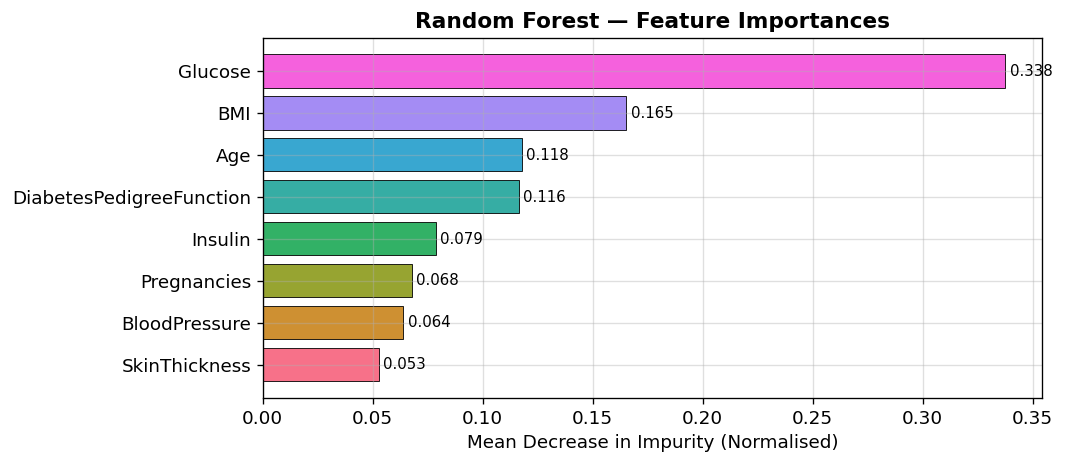


✓ Random Forest trained.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Model 2 — Random Forest (non-linear ensemble)
#
# Random Forest builds many independent decision trees, each trained on a
# random bootstrap sample of the data and a random subset of features.
# Prediction is the average probability across all trees.
#
# Key hyperparameters:
#   n_estimators  — number of trees (more = better up to a point)
#   max_depth     — how deep each tree can grow (controls overfitting)
#   min_samples_split — min samples required to split a node
# ─────────────────────────────────────────────────────────────────────────────

print("Training Model 2: Random Forest...")
print("-" * 50)

rf_model = RandomForestClassifier(
    n_estimators=200,        # 200 decision trees in the forest
    max_depth=10,            # limit depth to control overfitting
    min_samples_split=10,    # require at least 10 samples to make a split
    min_samples_leaf=4,      # require at least 4 samples in each leaf
    max_features="sqrt",     # use sqrt(n_features) features per split (standard for classification)
    random_state=RANDOM_STATE,
    n_jobs=-1,               # use all CPU cores
)
rf_model.fit(X_train_scaled, y_train)

print(f"  Train Accuracy:      {rf_model.score(X_train_scaled, y_train):.4f}")
print(f"  Validation Accuracy: {rf_model.score(X_val_scaled,   y_val):.4f}")

# ── Feature importances — which features does the forest rely on most?
print("\n  Feature importances (by mean decrease in impurity):")
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_,
}).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(
    importance_df["Feature"][::-1],
    importance_df["Importance"][::-1],
    color=sns.color_palette("husl", len(feature_cols)),
    edgecolor="black",
    linewidth=0.5,
)
ax.set_title("Random Forest — Feature Importances", fontweight="bold")
ax.set_xlabel("Mean Decrease in Impurity (Normalised)")
for bar, val in zip(bars, importance_df["Importance"][::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print("\n✓ Random Forest trained.")

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Model 3 — XGBoost or Gradient Boosting (advanced boosted ensemble)
#
# Gradient boosting builds trees SEQUENTIALLY. Each new tree corrects the
# errors of all previous trees by fitting to the residual gradient.
#
# This differs from Random Forest (which uses parallel independent trees).
# Boosting is typically more accurate but also more prone to overfitting.
#
# XGBoost adds L1/L2 regularisation, approximate tree algorithms, and
# parallel computation, making it extremely efficient.
# ─────────────────────────────────────────────────────────────────────────────

print("Training Model 3: Gradient Boosting / XGBoost...")
print("-" * 50)

if XGBOOST_AVAILABLE:
    boost_model = XGBClassifier(
        n_estimators=200,           # number of boosting rounds
        max_depth=4,                # shallow trees — each round corrects a little
        learning_rate=0.05,         # small learning rate + more trees = better generalisation
        subsample=0.8,              # fraction of training samples per tree (stochastic boosting)
        colsample_bytree=0.8,       # fraction of features per tree
        gamma=1.0,                  # minimum loss reduction to make a split (regularisation)
        reg_alpha=0.1,              # L1 regularisation on weights
        reg_lambda=1.0,             # L2 regularisation on weights
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        verbosity=0,
    )
    model_name = "XGBoost"
else:
    boost_model = GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        min_samples_leaf=4,
        random_state=RANDOM_STATE,
    )
    model_name = "GradientBoosting"

boost_model.fit(X_train_scaled, y_train)

print(f"  Model type: {model_name}")
print(f"  Train Accuracy:      {boost_model.score(X_train_scaled, y_train):.4f}")
print(f"  Validation Accuracy: {boost_model.score(X_val_scaled,   y_val):.4f}")

# ── Summary of all trained models
print("\n" + "=" * 60)
print("ALL MODELS TRAINED — SUMMARY")
print("=" * 60)
models = {
    "Logistic Regression": lr_model,
    "Random Forest":       rf_model,
    f"{model_name}":       boost_model,
}
for name, model in models.items():
    val_acc = model.score(X_val_scaled, y_val)
    print(f"  {name:<30}: val_accuracy = {val_acc:.4f}")

print("\n✓ All models trained. Next: generate probability predictions for ROC analysis.")

Training Model 3: Gradient Boosting / XGBoost...
--------------------------------------------------
  Model type: XGBoost
  Train Accuracy:      0.9413
  Validation Accuracy: 0.7597

ALL MODELS TRAINED — SUMMARY
  Logistic Regression           : val_accuracy = 0.7792
  Random Forest                 : val_accuracy = 0.7792
  XGBoost                       : val_accuracy = 0.7597

✓ All models trained. Next: generate probability predictions for ROC analysis.


---
## Part 8: Probability Predictions and Threshold Demonstrations

### From Trained Model to Probability Scores

Scikit-learn classifiers expose two prediction methods:
- `model.predict(X)` → Hard labels (0 or 1) using the default threshold of 0.5
- `model.predict_proba(X)` → Probability array of shape `[n_samples, n_classes]`

For ROC curves we ALWAYS use `predict_proba()` — the raw probabilities before thresholding.

> **Column 0** = probability of class 0 (no diabetes)  
> **Column 1** = probability of class 1 (diabetes) ← this is what we use

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Extract probability predictions from all three models
#
# We use the TEST set here for all final evaluations.
# The validation set was only used for threshold tuning (Part 10).
# ─────────────────────────────────────────────────────────────────────────────

# ── Get probability scores for the positive class (column index 1)
y_prob_lr   = lr_model.predict_proba(X_test_scaled)[:, 1]
y_prob_rf   = rf_model.predict_proba(X_test_scaled)[:, 1]
y_prob_xgb  = boost_model.predict_proba(X_test_scaled)[:, 1]

# ── Hard predictions using default threshold 0.5
y_pred_lr   = lr_model.predict(X_test_scaled)
y_pred_rf   = rf_model.predict(X_test_scaled)
y_pred_xgb  = boost_model.predict(X_test_scaled)

# ── Inspect a sample of predictions
sample_df = pd.DataFrame({
    "True Label":     y_test.values[:10],
    "LR Probability": y_prob_lr[:10].round(3),
    "LR Predicted":   y_pred_lr[:10],
    "RF Probability": y_prob_rf[:10].round(3),
    "RF Predicted":   y_pred_rf[:10],
    "XGB Probability":y_prob_xgb[:10].round(3),
    "XGB Predicted":  y_pred_xgb[:10],
})
print("Sample predictions for the first 10 test instances:")
print(sample_df.to_string(index=False))
print()
print("  'Probability' = model's confidence that this person HAS diabetes.")
print("  'Predicted'   = hard label at threshold 0.5.")
print("  When probability > 0.5 → Predicted = 1 (diabetes)")

Sample predictions for the first 10 test instances:
 True Label  LR Probability  LR Predicted  RF Probability  RF Predicted  XGB Probability  XGB Predicted
          0           0.608             1           0.634             1            0.779              1
          0           0.079             0           0.162             0            0.028              0
          0           0.302             0           0.214             0            0.076              0
          1           0.250             0           0.321             0            0.391              0
          0           0.030             0           0.068             0            0.019              0
          0           0.198             0           0.205             0            0.197              0
          1           0.396             0           0.381             0            0.299              0
          1           0.928             1           0.725             1            0.853              1
          0 

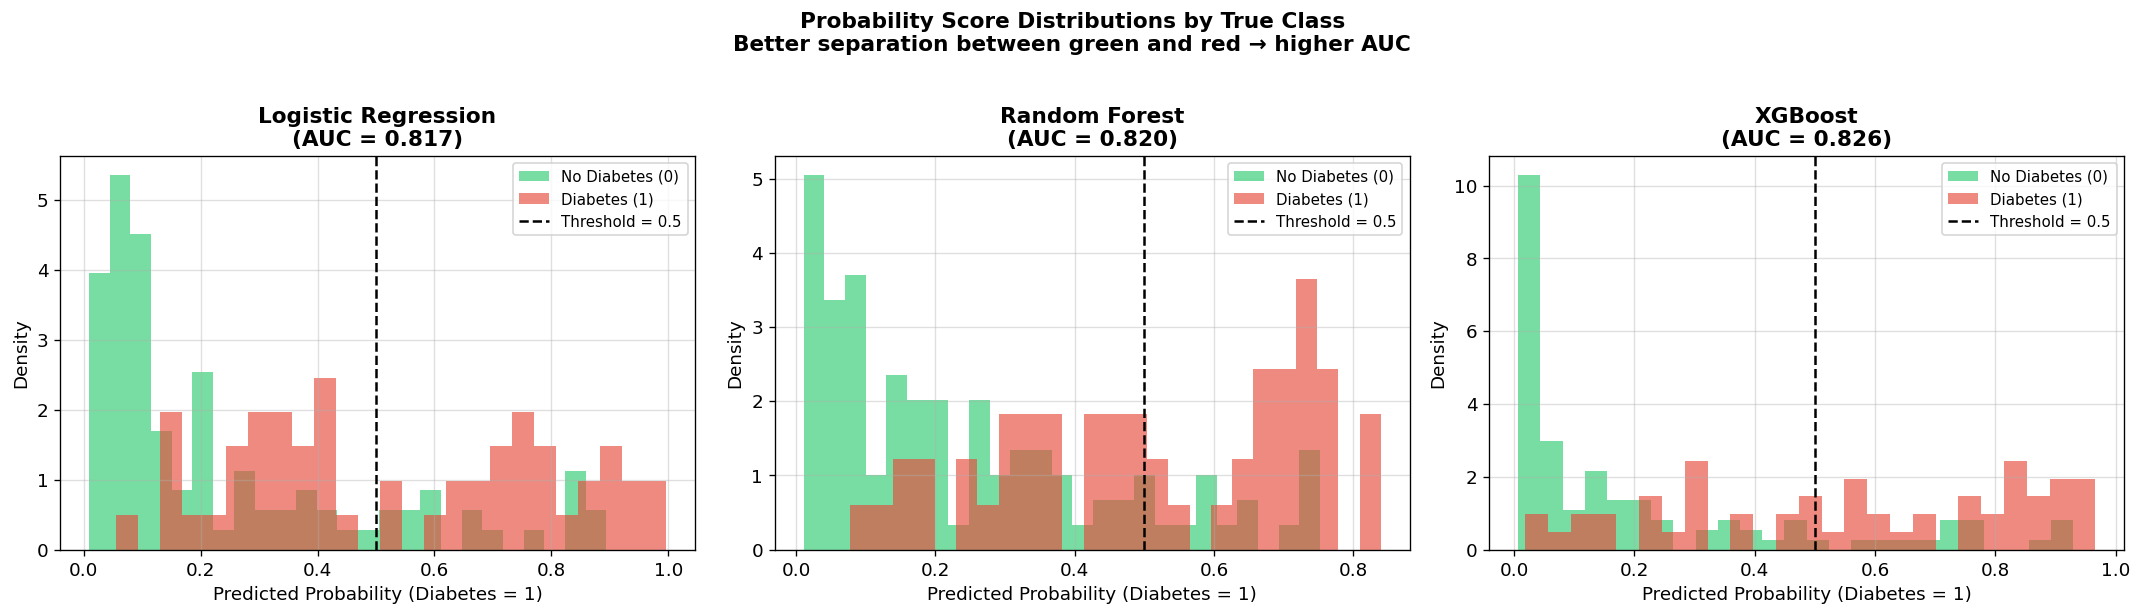


Key observations:
  • The more separated the two distributions, the higher the AUC.
  • Samples in the overlap zone are the 'hard' borderline cases.
  • Moving the dashed threshold line left → catch more positives (↑ TPR, ↑ FPR).
  • Moving the threshold right → be more conservative (↓ TPR, ↓ FPR).


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Visualise the probability distributions produced by each model
#
# A well-calibrated model should produce:
#   - Probabilities near 0 for true negatives
#   - Probabilities near 1 for true positives
#   - Clear separation between the two distributions
#
# Poor separation → low AUC
# Good separation → high AUC
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

model_probs = [
    ("Logistic Regression", y_prob_lr),
    ("Random Forest",       y_prob_rf),
    (model_name,            y_prob_xgb),
]
colors_neg = "#2ecc71"
colors_pos = "#e74c3c"

for ax, (name, probs) in zip(axes, model_probs):
    # Separate probabilities by true class
    neg_probs = probs[y_test == 0]
    pos_probs = probs[y_test == 1]

    ax.hist(neg_probs, bins=25, alpha=0.65, color=colors_neg, label="No Diabetes (0)", density=True)
    ax.hist(pos_probs, bins=25, alpha=0.65, color=colors_pos, label="Diabetes (1)",    density=True)

    # Mark the default threshold
    ax.axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="Threshold = 0.5")

    # Compute overlap (rough separation quality)
    auc_val = roc_auc_score(y_test, probs)
    ax.set_title(f"{name}\n(AUC = {auc_val:.3f})", fontweight="bold")
    ax.set_xlabel("Predicted Probability (Diabetes = 1)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.suptitle(
    "Probability Score Distributions by True Class\n"
    "Better separation between green and red → higher AUC",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("  • The more separated the two distributions, the higher the AUC.")
print("  • Samples in the overlap zone are the 'hard' borderline cases.")
print("  • Moving the dashed threshold line left → catch more positives (↑ TPR, ↑ FPR).")
print("  • Moving the threshold right → be more conservative (↓ TPR, ↓ FPR).")

---
## Part 9: Building and Reading ROC Curves

### Step-by-Step ROC Construction for Logistic Regression

Before plotting all models together, let's manually walk through the ROC curve construction
for Logistic Regression — so you can see exactly what `roc_curve()` does internally.

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Manually build an ROC curve step by step (Logistic Regression)
#
# This cell implements the ROC algorithm from scratch to make the construction
# completely transparent. We then compare it against sklearn's roc_curve().
# ─────────────────────────────────────────────────────────────────────────────

# ── Manual ROC construction
def manual_roc_curve(y_true, y_scores, n_thresholds=20):
    """
    Build an ROC curve manually for educational purposes.
    
    For each threshold t in [0, 1]:
      1. Classify sample as 1 if score >= t, else 0
      2. Build confusion matrix
      3. Compute TPR = TP / (TP + FN)
      4. Compute FPR = FP / (FP + TN)
    
    Returns: list of (threshold, TPR, FPR, TP, FP, TN, FN) tuples
    """
    thresholds = np.linspace(0, 1, n_thresholds)
    results = []
    
    y_true = np.array(y_true)
    
    for t in thresholds:
        y_pred_t = (y_scores >= t).astype(int)
        
        TP = ((y_pred_t == 1) & (y_true == 1)).sum()
        TN = ((y_pred_t == 0) & (y_true == 0)).sum()
        FP = ((y_pred_t == 1) & (y_true == 0)).sum()
        FN = ((y_pred_t == 0) & (y_true == 1)).sum()
        
        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0.0
        
        results.append({
            "Threshold": round(t, 3),
            "TP": TP, "TN": TN, "FP": FP, "FN": FN,
            "TPR (Recall)": round(TPR, 4),
            "FPR": round(FPR, 4),
            "Specificity": round(1 - FPR, 4),
        })
    
    return pd.DataFrame(results)

manual_df = manual_roc_curve(y_test, y_prob_lr, n_thresholds=11)

print("ROC curve data points (Logistic Regression, 11 thresholds):")
print("=" * 80)
print(manual_df.to_string(index=False))
print()
print("Key observations from the table:")
print("  • Threshold=0.0 → predict EVERYTHING as positive → TPR=1.0, FPR=1.0 → point (1,1)")
print("  • Threshold=1.0 → predict EVERYTHING as negative → TPR=0.0, FPR=0.0 → point (0,0)")
print("  • Threshold=0.5 → the DEFAULT threshold used by .predict()")
print("  • As threshold DECREASES: TPR increases (catch more positives), FPR also increases (more false alarms)")
print("  • As threshold INCREASES: FPR decreases (fewer false alarms), TPR also decreases (miss more positives)")

ROC curve data points (Logistic Regression, 11 thresholds):
 Threshold  TP  TN  FP  FN  TPR (Recall)  FPR  Specificity
       0.0  54   0 100   0        1.0000 1.00         0.00
       0.1  53  40  60   1        0.9815 0.60         0.40
       0.2  48  60  40   6        0.8889 0.40         0.60
       0.3  43  72  28  11        0.7963 0.28         0.72
       0.4  32  79  21  22        0.5926 0.21         0.79
       0.5  27  82  18  27        0.5000 0.18         0.82
       0.6  25  87  13  29        0.4630 0.13         0.87
       0.7  20  92   8  34        0.3704 0.08         0.92
       0.8  11  94   6  43        0.2037 0.06         0.94
       0.9   7 100   0  47        0.1296 0.00         1.00
       1.0   0 100   0  54        0.0000 0.00         1.00

Key observations from the table:
  • Threshold=0.0 → predict EVERYTHING as positive → TPR=1.0, FPR=1.0 → point (1,1)
  • Threshold=1.0 → predict EVERYTHING as negative → TPR=0.0, FPR=0.0 → point (0,0)
  • Threshold=0.5 → the DEFAUL

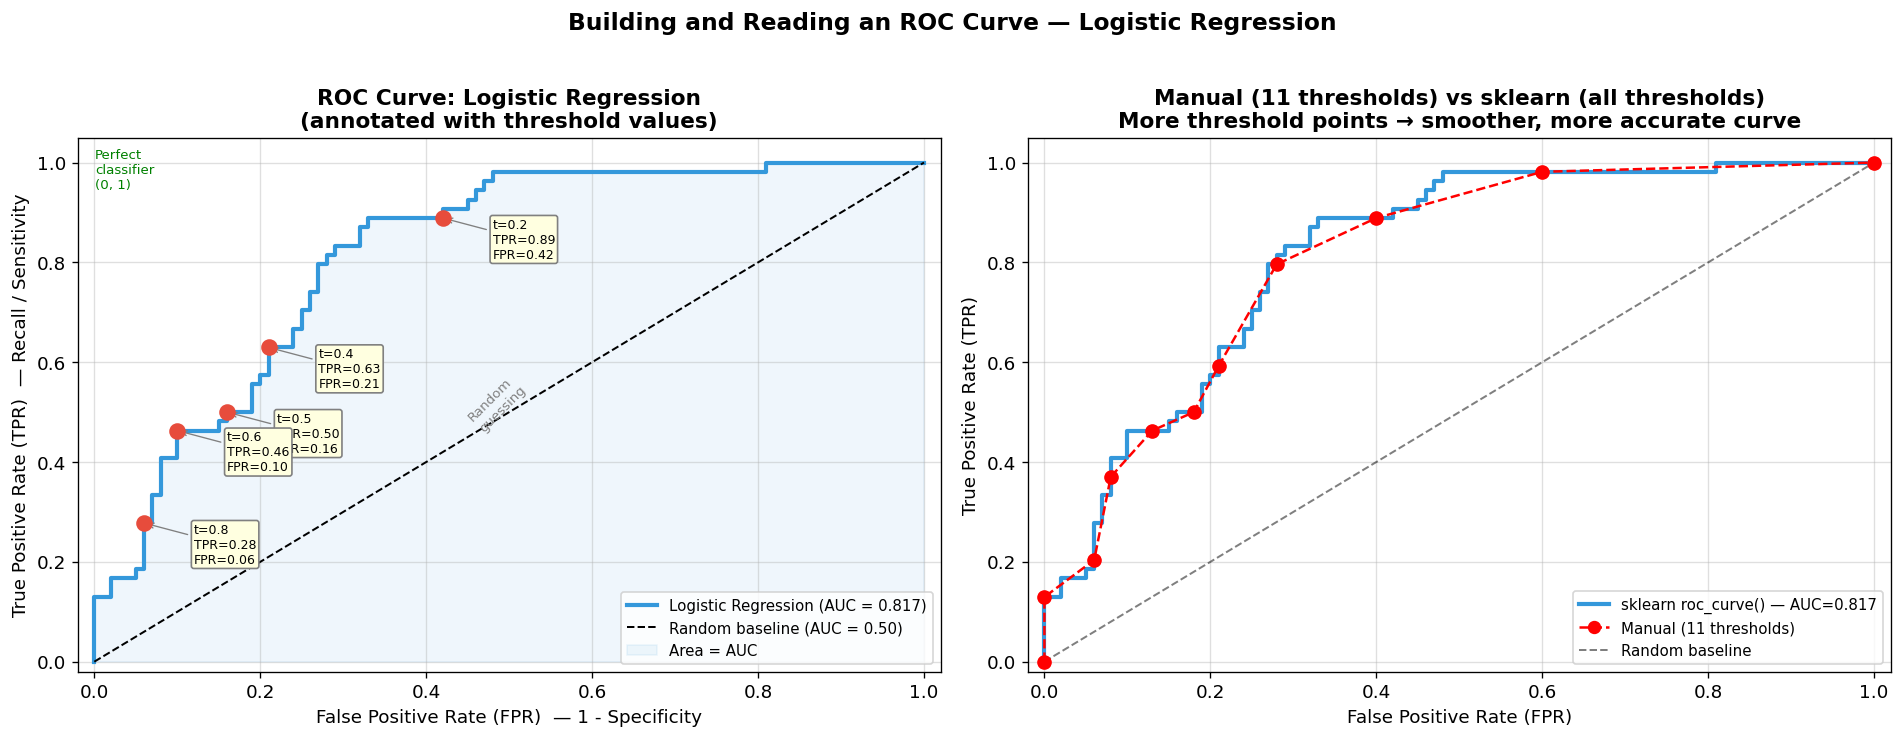


AUC Summary:
  sklearn roc_auc_score(): 0.8172
  Interpretation: The LR model correctly ranks a random diabetic patient
  above a random non-diabetic patient 81.7% of the time.


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Plot the step-by-step ROC curve for Logistic Regression
#       and show how threshold changes move points along the curve
# ─────────────────────────────────────────────────────────────────────────────

# ── Compute the smooth ROC curve using sklearn (uses every unique threshold)
fpr_lr_sk, tpr_lr_sk, thresholds_lr_sk = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr_sk, tpr_lr_sk)

# ── Selected thresholds to highlight on the curve
highlight_thresholds = [0.2, 0.4, 0.5, 0.6, 0.8]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left panel: smooth sklearn ROC curve with annotated threshold points
ax = axes[0]
ax.plot(fpr_lr_sk, tpr_lr_sk, color="#3498db", lw=2.5,
        label=f"Logistic Regression (AUC = {auc_lr:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random baseline (AUC = 0.50)")
ax.fill_between(fpr_lr_sk, tpr_lr_sk, alpha=0.08, color="#3498db", label="Area = AUC")

# Annotate specific thresholds on the curve
for t in highlight_thresholds:
    # Find the closest threshold
    idx = np.argmin(np.abs(thresholds_lr_sk - t))
    fpr_t = fpr_lr_sk[idx]
    tpr_t = tpr_lr_sk[idx]
    ax.scatter(fpr_t, tpr_t, s=80, zorder=5, color="#e74c3c")
    ax.annotate(
        f"t={t:.1f}\nTPR={tpr_t:.2f}\nFPR={fpr_t:.2f}",
        xy=(fpr_t, tpr_t),
        xytext=(fpr_t + 0.06, tpr_t - 0.08),
        fontsize=7.5,
        arrowprops=dict(arrowstyle="->", color="gray", lw=0.8),
        bbox=dict(boxstyle="round,pad=0.2", facecolor="lightyellow", edgecolor="gray"),
    )

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
ax.set_xlabel("False Positive Rate (FPR)  — 1 - Specificity")
ax.set_ylabel("True Positive Rate (TPR)  — Recall / Sensitivity")
ax.set_title("ROC Curve: Logistic Regression\n(annotated with threshold values)", fontweight="bold")
ax.legend(loc="lower right", fontsize=9)

# Add corner annotations
ax.text(0.02, 0.98, "Perfect\nclassifier\n(0, 1)", fontsize=8, color="green",
        va="top", ha="left", transform=ax.transAxes)
ax.text(0.45, 0.45, "Random\nguessing", fontsize=8, color="gray",
        rotation=45, transform=ax.transAxes)

# ── Right panel: manual 11-point curve vs sklearn smooth curve
ax2 = axes[1]
# sklearn smooth curve
ax2.plot(fpr_lr_sk, tpr_lr_sk, color="#3498db", lw=2.5, label=f"sklearn roc_curve() — AUC={auc_lr:.3f}")
# Manual 11-point curve
manual_sorted = manual_df.sort_values("FPR")
ax2.plot(manual_sorted["FPR"], manual_sorted["TPR (Recall)"],
         "ro--", markersize=7, lw=1.5, label="Manual (11 thresholds)")
ax2.scatter(manual_sorted["FPR"], manual_sorted["TPR (Recall)"],
            c="red", s=60, zorder=5)
ax2.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.5, label="Random baseline")

ax2.set_xlim([-0.02, 1.02])
ax2.set_ylim([-0.02, 1.05])
ax2.set_xlabel("False Positive Rate (FPR)")
ax2.set_ylabel("True Positive Rate (TPR)")
ax2.set_title("Manual (11 thresholds) vs sklearn (all thresholds)\n"
              "More threshold points → smoother, more accurate curve", fontweight="bold")
ax2.legend(loc="lower right", fontsize=9)

plt.suptitle("Building and Reading an ROC Curve — Logistic Regression", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nAUC Summary:")
print(f"  sklearn roc_auc_score(): {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"  Interpretation: The LR model correctly ranks a random diabetic patient")
print(f"  above a random non-diabetic patient {roc_auc_score(y_test, y_prob_lr)*100:.1f}% of the time.")

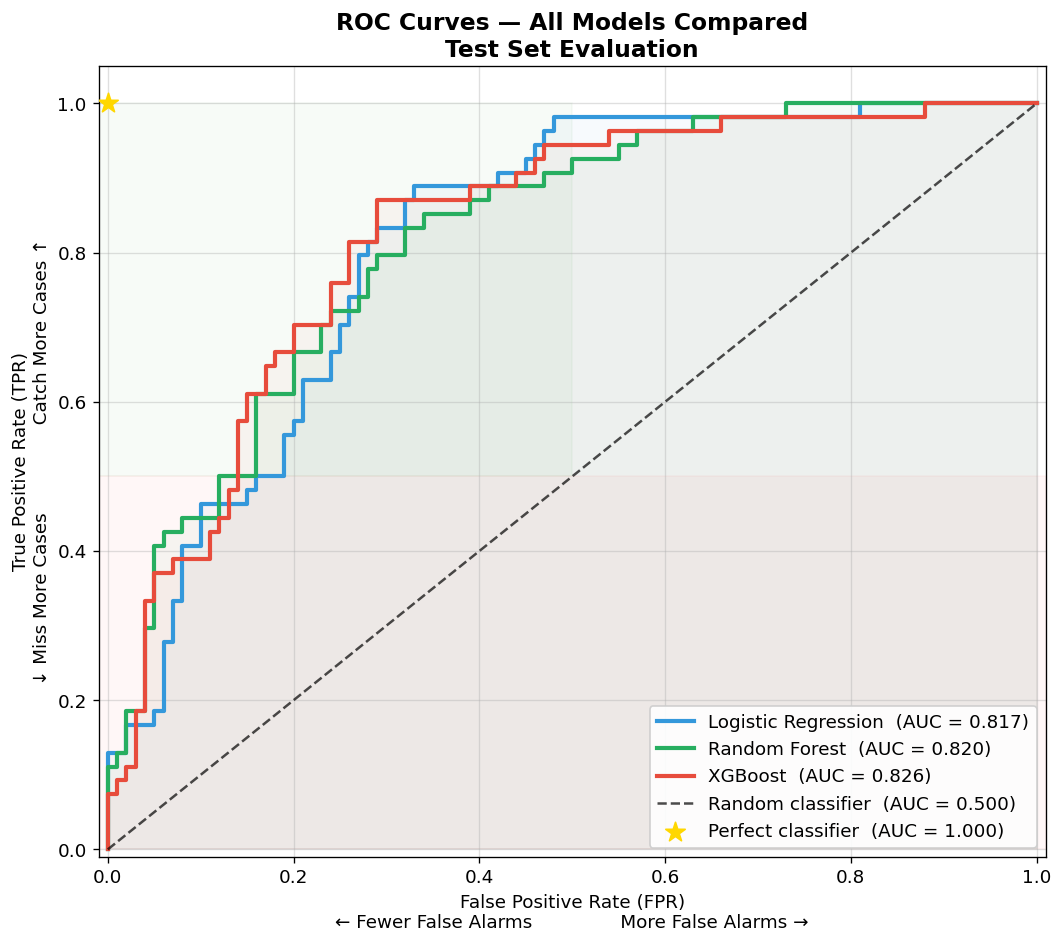


AUC Score Comparison (Test Set):
Model                               AUC       Grade
-------------------------------------------------------
  Logistic Regression            0.8172        Good
  Random Forest                  0.8200        Good
  XGBoost                        0.8265        Good
-------------------------------------------------------

  Best model by AUC: XGBoost

Note: AUC is threshold-independent — it measures OVERALL discrimination ability.
      A model with AUC=0.85 is better at ranking positives above negatives,
      regardless of what threshold you choose.


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: ROC curves for ALL THREE models on one plot
#       This is the key comparison chart.
# ─────────────────────────────────────────────────────────────────────────────

# ── Compute ROC data for all models
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_prob_lr)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

auc_lr  = auc(fpr_lr,  tpr_lr)
auc_rf  = auc(fpr_rf,  tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

model_roc_data = [
    ("Logistic Regression", fpr_lr,  tpr_lr,  auc_lr,  "#3498db"),
    ("Random Forest",       fpr_rf,  tpr_rf,  auc_rf,  "#27ae60"),
    (model_name,            fpr_xgb, tpr_xgb, auc_xgb, "#e74c3c"),
]

fig, ax = plt.subplots(figsize=(9, 8))

# ── Plot each model's ROC curve
for name, fpr, tpr, auc_val, color in model_roc_data:
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f"{name}  (AUC = {auc_val:.3f})")
    ax.fill_between(fpr, tpr, alpha=0.04, color=color)

# ── Diagonal reference line (random classifier)
ax.plot([0, 1], [0, 1], "k--", lw=1.5, alpha=0.7, label="Random classifier  (AUC = 0.500)")

# ── Perfect classifier reference point
ax.scatter([0], [1], s=150, c="gold", zorder=10, marker="*", label="Perfect classifier  (AUC = 1.000)")

# ── Formatting
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
ax.set_xlabel("False Positive Rate (FPR)\n← Fewer False Alarms               More False Alarms →",
              fontsize=11)
ax.set_ylabel("True Positive Rate (TPR)\n↓ Miss More Cases               Catch More Cases ↑",
              fontsize=11)
ax.set_title("ROC Curves — All Models Compared\nTest Set Evaluation",
             fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11, framealpha=0.9)

# ── Add a guide for interpreting AUC regions
ax.axhspan(0, 0.5, xmin=0, xmax=1, alpha=0.03, color="red")
ax.axhspan(0.5, 1, xmin=0, xmax=0.5, alpha=0.03, color="green")

plt.tight_layout()
plt.show()

# ── Summary table
print("\nAUC Score Comparison (Test Set):")
print("=" * 55)
print(f"{'Model':<30} {'AUC':>8}  {'Grade':>10}")
print("-" * 55)

def grade_auc(auc_val):
    if auc_val >= 0.90: return "Excellent"
    elif auc_val >= 0.80: return "Good"
    elif auc_val >= 0.70: return "Fair"
    elif auc_val >= 0.60: return "Poor"
    else: return "Fail"

for name, _, _, auc_val, _ in model_roc_data:
    print(f"  {name:<28} {auc_val:>8.4f}  {grade_auc(auc_val):>10}")

print("-" * 55)
best_name = model_roc_data[np.argmax([d[3] for d in model_roc_data])][0]
print(f"\n  Best model by AUC: {best_name}")
print("\nNote: AUC is threshold-independent — it measures OVERALL discrimination ability.")
print("      A model with AUC=0.85 is better at ranking positives above negatives,")
print("      regardless of what threshold you choose.")

---
## Part 10: Threshold Tuning — Finding the Optimal Cut-off

### Why Tune the Threshold?

The default threshold of **0.5** is rarely optimal. The right threshold depends on the
**cost of each type of error** in your specific problem:

| Scenario | Priority | Threshold Strategy |
|----------|----------|--------------------|
| Cancer screening | Catch every case (minimise FN) | **Low threshold** → high TPR, accept higher FPR |
| Drug approval review | Only approve safe drugs (minimise FP) | **High threshold** → high Specificity, accept lower TPR |
| Spam filter | Balance user experience | **Medium threshold** → balance FPR/TPR |

### The Youden's J Statistic

A common threshold selection method is to maximise **Youden's J index**:

$$J = \text{TPR} + \text{Specificity} - 1 = \text{TPR} - \text{FPR}$$

This selects the threshold that maximises the distance from the diagonal (random classifier).
It treats FP and FN errors as equally costly — adjust if your costs differ.

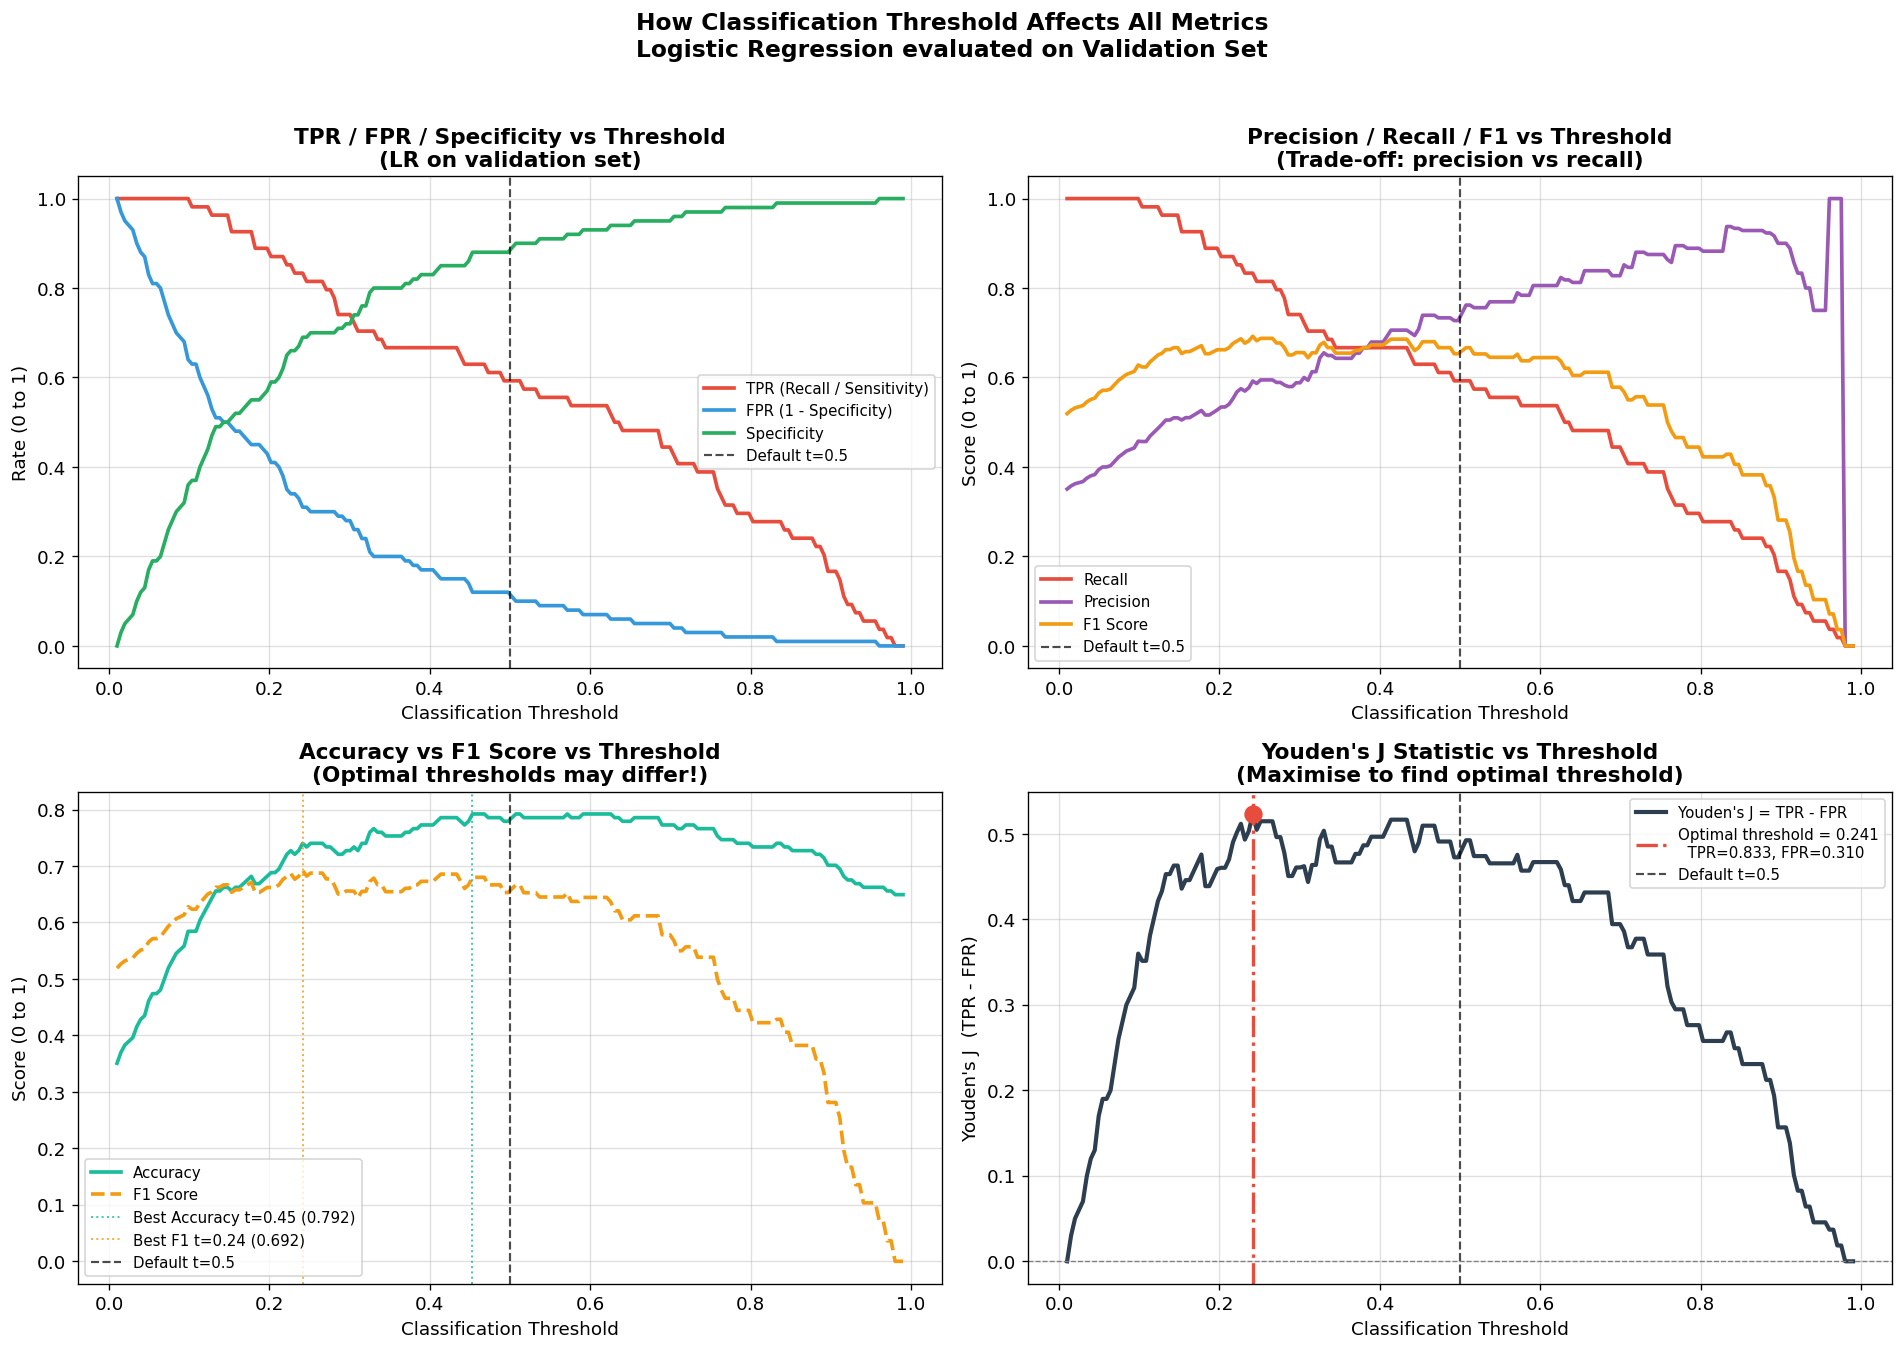


Youden's J Optimal Threshold (Logistic Regression, validation set): 0.241
  → At this threshold: TPR = 0.833, FPR = 0.310
  → Compare default (0.5): TPR = 0.593


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Threshold vs TPR / FPR / Precision / F1 curves for all models
#
# This plot is the most instructive visualisation in the whole notebook.
# It shows EXACTLY how every metric changes as the threshold moves from 0 to 1.
# ─────────────────────────────────────────────────────────────────────────────

def compute_threshold_metrics(y_true, y_probs, thresholds):
    """
    For each threshold, compute TPR, FPR, Specificity, Precision, F1, Accuracy.
    Returns a DataFrame indexed by threshold.
    """
    rows = []
    for t in thresholds:
        y_pred_t = (y_probs >= t).astype(int)
        
        TP = ((y_pred_t == 1) & (y_true == 1)).sum()
        TN = ((y_pred_t == 0) & (y_true == 0)).sum()
        FP = ((y_pred_t == 1) & (y_true == 0)).sum()
        FN = ((y_pred_t == 0) & (y_true == 1)).sum()
        
        tpr  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        fpr  = FP / (FP + TN) if (FP + TN) > 0 else 0.0
        spec = 1.0 - fpr
        prec = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        f1   = 2 * prec * tpr / (prec + tpr) if (prec + tpr) > 0 else 0.0
        acc  = (TP + TN) / len(y_true)
        
        rows.append({
            "Threshold": t,
            "TPR (Recall)": tpr,
            "FPR": fpr,
            "Specificity": spec,
            "Precision": prec,
            "F1 Score": f1,
            "Accuracy": acc,
        })
    return pd.DataFrame(rows)

thresholds_sweep = np.linspace(0.01, 0.99, 200)

# Use Logistic Regression for this deep dive (clearer curves)
# We use the VALIDATION set here for threshold selection (not test set!)
y_val_prob_lr = lr_model.predict_proba(X_val_scaled)[:, 1]
metrics_df = compute_threshold_metrics(y_val.values, y_val_prob_lr, thresholds_sweep)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ── Panel 1: TPR vs FPR vs Threshold
ax = axes[0, 0]
ax.plot(metrics_df["Threshold"], metrics_df["TPR (Recall)"], color="#e74c3c", lw=2.2,
        label="TPR (Recall / Sensitivity)")
ax.plot(metrics_df["Threshold"], metrics_df["FPR"], color="#3498db", lw=2.2,
        label="FPR (1 - Specificity)")
ax.plot(metrics_df["Threshold"], metrics_df["Specificity"], color="#27ae60", lw=2.2,
        label="Specificity")
ax.axvline(0.5, color="black", linestyle="--", lw=1.3, alpha=0.7, label="Default t=0.5")
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Rate (0 to 1)")
ax.set_title("TPR / FPR / Specificity vs Threshold\n(LR on validation set)", fontweight="bold")
ax.legend(fontsize=9)

# ── Panel 2: Precision, Recall, F1 vs Threshold
ax = axes[0, 1]
ax.plot(metrics_df["Threshold"], metrics_df["TPR (Recall)"], color="#e74c3c", lw=2.2, label="Recall")
ax.plot(metrics_df["Threshold"], metrics_df["Precision"],    color="#9b59b6", lw=2.2, label="Precision")
ax.plot(metrics_df["Threshold"], metrics_df["F1 Score"],     color="#f39c12", lw=2.2, label="F1 Score")
ax.axvline(0.5, color="black", linestyle="--", lw=1.3, alpha=0.7, label="Default t=0.5")
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score (0 to 1)")
ax.set_title("Precision / Recall / F1 vs Threshold\n(Trade-off: precision vs recall)", fontweight="bold")
ax.legend(fontsize=9)

# ── Panel 3: Accuracy vs Threshold (shows why accuracy alone is not enough)
ax = axes[1, 0]
ax.plot(metrics_df["Threshold"], metrics_df["Accuracy"], color="#1abc9c", lw=2.2, label="Accuracy")
ax.plot(metrics_df["Threshold"], metrics_df["F1 Score"], color="#f39c12", lw=2.2, linestyle="--",
        label="F1 Score")

# Mark peak accuracy and peak F1
best_acc_t  = metrics_df.loc[metrics_df["Accuracy"].idxmax(), "Threshold"]
best_f1_t   = metrics_df.loc[metrics_df["F1 Score"].idxmax(), "Threshold"]
best_acc_v  = metrics_df["Accuracy"].max()
best_f1_v   = metrics_df["F1 Score"].max()

ax.axvline(best_acc_t, color="#1abc9c", lw=1.2, linestyle=":", alpha=0.8,
           label=f"Best Accuracy t={best_acc_t:.2f} ({best_acc_v:.3f})")
ax.axvline(best_f1_t, color="#f39c12", lw=1.2, linestyle=":", alpha=0.8,
           label=f"Best F1 t={best_f1_t:.2f} ({best_f1_v:.3f})")
ax.axvline(0.5, color="black", linestyle="--", lw=1.3, alpha=0.7, label="Default t=0.5")

ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score (0 to 1)")
ax.set_title("Accuracy vs F1 Score vs Threshold\n(Optimal thresholds may differ!)", fontweight="bold")
ax.legend(fontsize=9)

# ── Panel 4: Youden's J — find the optimal threshold
youden_j = metrics_df["TPR (Recall)"] - metrics_df["FPR"]
metrics_df["Youden_J"] = youden_j
best_j_idx = youden_j.idxmax()
best_j_t   = metrics_df.loc[best_j_idx, "Threshold"]
best_j_tpr = metrics_df.loc[best_j_idx, "TPR (Recall)"]
best_j_fpr = metrics_df.loc[best_j_idx, "FPR"]

ax = axes[1, 1]
ax.plot(metrics_df["Threshold"], youden_j, color="#2c3e50", lw=2.5, label="Youden's J = TPR - FPR")
ax.axvline(best_j_t, color="#e74c3c", lw=2, linestyle="-.",
           label=f"Optimal threshold = {best_j_t:.3f}\n  TPR={best_j_tpr:.3f}, FPR={best_j_fpr:.3f}")
ax.axvline(0.5, color="black", linestyle="--", lw=1.3, alpha=0.7, label="Default t=0.5")
ax.axhline(0, color="gray", lw=0.8, linestyle="--")
ax.scatter([best_j_t], [youden_j.max()], s=100, c="#e74c3c", zorder=10)

ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Youden's J  (TPR - FPR)")
ax.set_title("Youden's J Statistic vs Threshold\n(Maximise to find optimal threshold)", fontweight="bold")
ax.legend(fontsize=9)

plt.suptitle(
    "How Classification Threshold Affects All Metrics\n"
    "Logistic Regression evaluated on Validation Set",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

print(f"\nYouden's J Optimal Threshold (Logistic Regression, validation set): {best_j_t:.3f}")
print(f"  → At this threshold: TPR = {best_j_tpr:.3f}, FPR = {best_j_fpr:.3f}")
print(f"  → Compare default (0.5): TPR = {metrics_df[metrics_df['Threshold'].between(0.49, 0.51)]['TPR (Recall)'].values[0]:.3f}")

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Demonstrate the effect of a specific threshold on a concrete example
#       Scenario: clinical screening — we want to catch >85% of diabetic patients
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 65)
print("CLINICAL SCENARIO: Diabetes Screening Programme")
print("Goal: Catch at least 85% of all diabetic patients (TPR ≥ 0.85)")
print("=" * 65)

# Use Logistic Regression on the TEST set for this demonstration
y_test_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

thresholds_demo = np.linspace(0.01, 0.99, 500)

# Find the threshold that gives TPR closest to 0.85 (but >= 0.85 if possible)
target_tpr = 0.85
best_t_for_goal = None
best_gap = float("inf")

for t in thresholds_demo:
    y_pred_t = (y_test_prob_lr >= t).astype(int)
    tpr_t = recall_score(y_test, y_pred_t, zero_division=0)
    gap   = abs(tpr_t - target_tpr)
    if gap < best_gap:
        best_gap = gap
        best_t_for_goal = t

y_pred_goal = (y_test_prob_lr >= best_t_for_goal).astype(int)

# ── Compare: default threshold vs clinical goal threshold
thresholds_compare = {
    "Default (t = 0.50)": (y_test_prob_lr >= 0.50).astype(int),
    f"Youden (t = {best_j_t:.2f})": (y_test_prob_lr >= best_j_t).astype(int),
    f"Clinical goal (t = {best_t_for_goal:.2f})": y_pred_goal,
}

print(f"\n{'Threshold':<30} {'TPR':>7} {'FPR':>7} {'Prec':>7} {'F1':>7} {'Acc':>7}")
print("-" * 70)

for label, y_pred_t in thresholds_compare.items():
    TP = ((y_pred_t == 1) & (y_test == 1)).sum()
    TN = ((y_pred_t == 0) & (y_test == 0)).sum()
    FP = ((y_pred_t == 1) & (y_test == 0)).sum()
    FN = ((y_pred_t == 0) & (y_test == 1)).sum()
    tpr_  = TP / (TP + FN) if (TP + FN) > 0 else 0
    fpr_  = FP / (FP + TN) if (FP + TN) > 0 else 0
    prec_ = TP / (TP + FP) if (TP + FP) > 0 else 0
    f1_   = 2*prec_*tpr_ / (prec_+tpr_) if (prec_+tpr_) > 0 else 0
    acc_  = (TP + TN) / len(y_test)
    print(f"  {label:<28} {tpr_:>7.3f} {fpr_:>7.3f} {prec_:>7.3f} {f1_:>7.3f} {acc_:>7.3f}")

print("-" * 70)
print("\nKey insight:")
print("  • Lowering the threshold to meet our 85% sensitivity goal:")
print("    - Catches MORE diabetic patients (higher TPR / Recall)")
print("    - But also flags MORE healthy people incorrectly (higher FPR)")
print("    - Precision drops (more false positives in the positive predictions)")
print("  • There is ALWAYS a trade-off. ROC curves make this trade-off visible.")

CLINICAL SCENARIO: Diabetes Screening Programme
Goal: Catch at least 85% of all diabetic patients (TPR ≥ 0.85)

Threshold                          TPR     FPR    Prec      F1     Acc
----------------------------------------------------------------------
  Default (t = 0.50)             0.500   0.180   0.600   0.545   0.708
  Youden (t = 0.24)              0.870   0.320   0.595   0.707   0.747
  Clinical goal (t = 0.25)       0.852   0.320   0.590   0.697   0.740
----------------------------------------------------------------------

Key insight:
  • Lowering the threshold to meet our 85% sensitivity goal:
    - Catches MORE diabetic patients (higher TPR / Recall)
    - But also flags MORE healthy people incorrectly (higher FPR)
    - Precision drops (more false positives in the positive predictions)
  • There is ALWAYS a trade-off. ROC curves make this trade-off visible.


---
## Part 11: Confusion Matrices and Full Classification Reports

### Confusion Matrices at Default Threshold (0.5)

The confusion matrix gives a complete picture of where the model succeeds and fails.
We display it for all three models side by side for easy comparison.

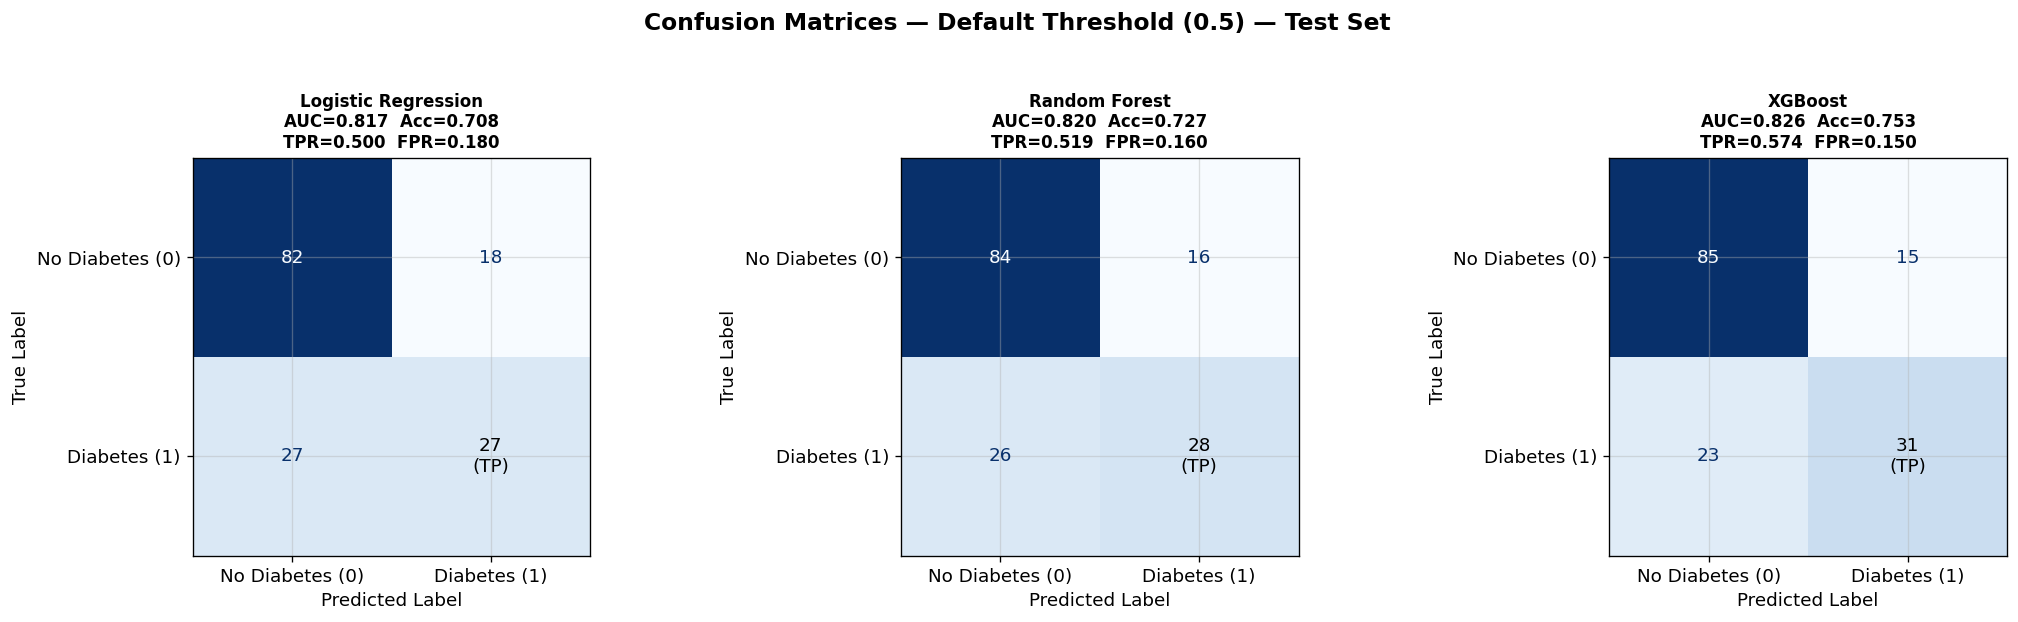

Confusion Matrix Cell Reference (diabetes prediction context):
------------------------------------------------------------
  TN (True Negative):   Predicted no diabetes → Actually no diabetes ✓
  TP (True Positive):   Predicted diabetes    → Actually has diabetes ✓
  FP (False Positive):  Predicted diabetes    → Actually no diabetes ✗  (Type I error)
  FN (False Negative):  Predicted no diabetes → Actually has diabetes ✗  (Type II error)

In a SCREENING context, FN (missed cases) is usually MORE costly than FP.
Lowering the threshold reduces FN but increases FP.


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Confusion matrices for all three models (default threshold 0.5)
# ─────────────────────────────────────────────────────────────────────────────

model_preds = [
    ("Logistic Regression", y_pred_lr,  y_prob_lr),
    ("Random Forest",       y_pred_rf,  y_prob_rf),
    (model_name,            y_pred_xgb, y_prob_xgb),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred, y_prob) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, y_pred)
    
    # Manual coloured heatmap
    # TN (top-left) and TP (bottom-right) should be green (correct)
    # FP (top-right) and FN (bottom-left) should be red (errors)
    cm_display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Diabetes (0)", "Diabetes (1)"],
    )
    cm_display.plot(ax=ax, cmap="Blues", colorbar=False)
    
    TP = cm[1, 1]; TN = cm[0, 0]; FP = cm[0, 1]; FN = cm[1, 0]
    tpr_  = TP / (TP + FN)
    fpr_  = FP / (FP + TN)
    auc_v = roc_auc_score(y_test, y_prob)
    acc_  = (TP + TN) / len(y_test)
    
    ax.set_title(
        f"{name}\n"
        f"AUC={auc_v:.3f}  Acc={acc_:.3f}\n"
        f"TPR={tpr_:.3f}  FPR={fpr_:.3f}",
        fontsize=10,
        fontweight="bold",
    )
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    
    # Annotate each cell with its meaning
    for (row, col), val in np.ndenumerate(cm):
        label = {(0,0): "TN", (0,1): "FP", (1,0): "FN", (1,1): "TP"}[(row, col)]
        color = "#c0392b" if label in ("FP", "FN") else "#1a5276"
        ax.texts[-1].set_text(f"{val}\n({label})")
        ax.texts[-1].set_color("white" if val > cm.max() * 0.5 else "black")

plt.suptitle(
    "Confusion Matrices — Default Threshold (0.5) — Test Set",
    fontsize=14,
    fontweight="bold",
    y=1.03,
)
plt.tight_layout()
plt.show()

# ── Annotated explanation of cells
print("Confusion Matrix Cell Reference (diabetes prediction context):")
print("-" * 60)
print("  TN (True Negative):   Predicted no diabetes → Actually no diabetes ✓")
print("  TP (True Positive):   Predicted diabetes    → Actually has diabetes ✓")
print("  FP (False Positive):  Predicted diabetes    → Actually no diabetes ✗  (Type I error)")
print("  FN (False Negative):  Predicted no diabetes → Actually has diabetes ✗  (Type II error)")
print()
print("In a SCREENING context, FN (missed cases) is usually MORE costly than FP.")
print("Lowering the threshold reduces FN but increases FP.")

FULL CLASSIFICATION REPORTS — Test Set (Default Threshold = 0.5)

──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
                 precision    recall  f1-score   support

No Diabetes (0)     0.7523    0.8200    0.7847       100
   Diabetes (1)     0.6000    0.5000    0.5455        54

       accuracy                         0.7078       154
      macro avg     0.6761    0.6600    0.6651       154
   weighted avg     0.6989    0.7078    0.7008       154


──────────────────────────────────────────────────
  Random Forest
──────────────────────────────────────────────────
                 precision    recall  f1-score   support

No Diabetes (0)     0.7636    0.8400    0.8000       100
   Diabetes (1)     0.6364    0.5185    0.5714        54

       accuracy                         0.7273       154
      macro avg     0.7000    0.6793    0.6857       154
   weighted avg     0.7190    0.7273    0.7199       154




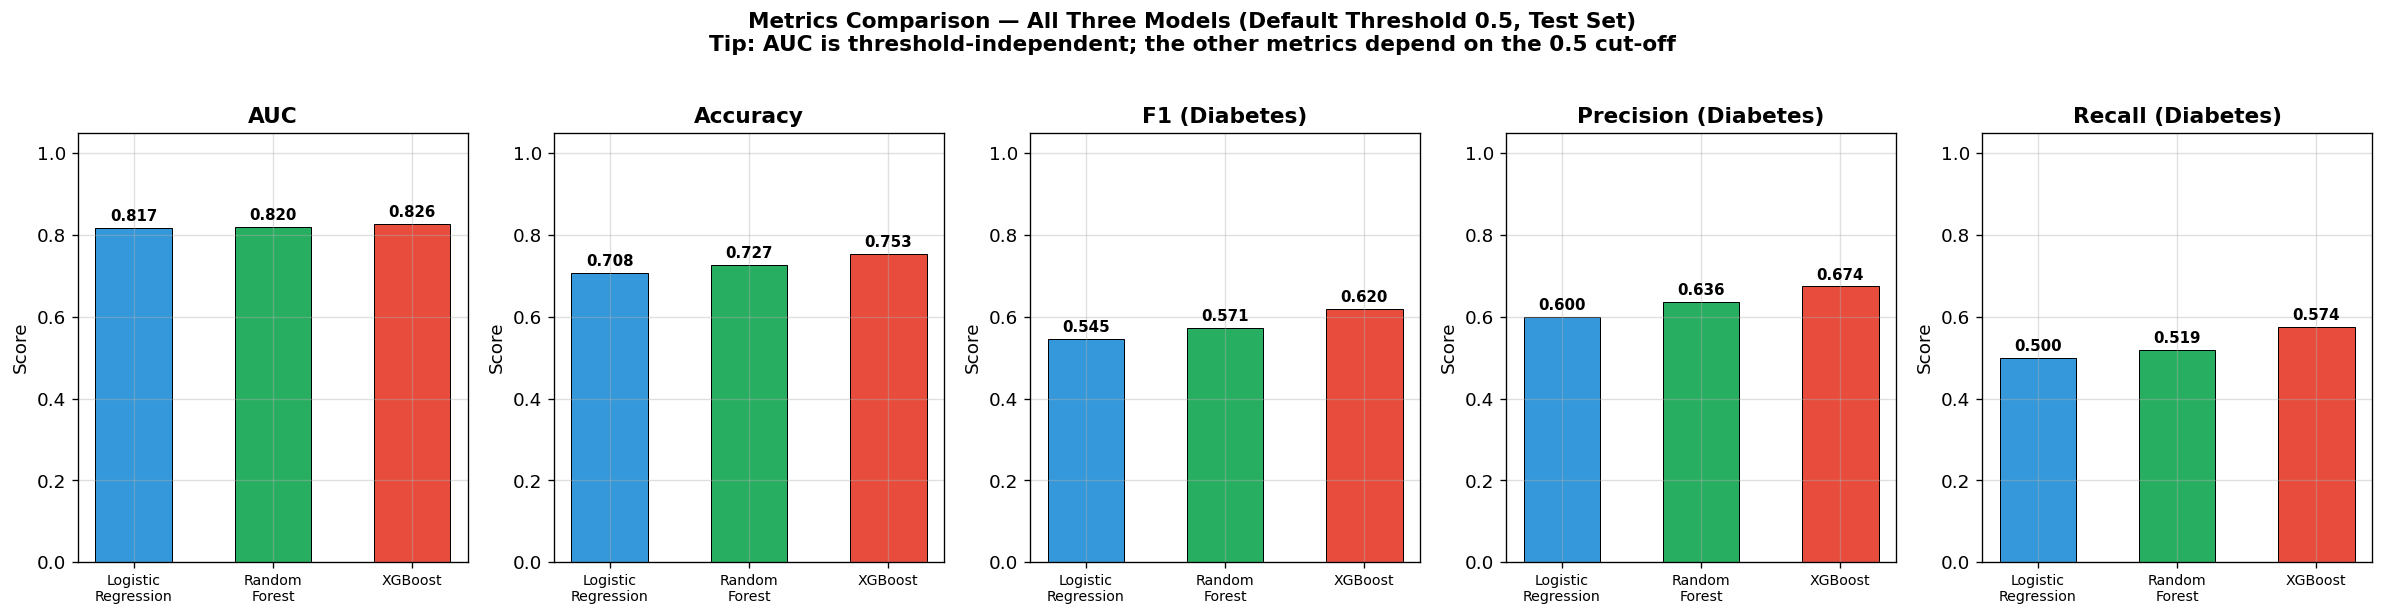

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Full classification reports and metrics comparison dashboard
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 70)
print("FULL CLASSIFICATION REPORTS — Test Set (Default Threshold = 0.5)")
print("=" * 70)

for name, y_pred, y_prob in model_preds:
    print(f"\n{'─' * 50}")
    print(f"  {name}")
    print(f"{'─' * 50}")
    print(classification_report(
        y_test, y_pred,
        target_names=["No Diabetes (0)", "Diabetes (1)"],
        digits=4,
    ))

# ── Collect metrics for bar chart comparison
metrics_summary = {}
for name, y_pred, y_prob in model_preds:
    metrics_summary[name] = {
        "AUC":       roc_auc_score(y_test, y_prob),
        "Accuracy":  accuracy_score(y_test, y_pred),
        "F1 (Diabetes)": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        "Precision (Diabetes)": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "Recall (Diabetes)": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
    }

metrics_df_compare = pd.DataFrame(metrics_summary).T

print("\n" + "=" * 70)
print("METRICS COMPARISON TABLE")
print("=" * 70)
print(metrics_df_compare.round(4).to_string())

# ── Bar chart dashboard
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
palette_models = ["#3498db", "#27ae60", "#e74c3c"]

for ax, metric in zip(axes, ["AUC", "Accuracy", "F1 (Diabetes)",
                              "Precision (Diabetes)", "Recall (Diabetes)"]):
    values = metrics_df_compare[metric].values
    bars = ax.bar(
        range(len(metrics_summary)),
        values,
        color=palette_models,
        edgecolor="black",
        linewidth=0.6,
        width=0.55,
    )
    ax.set_xticks(range(len(metrics_summary)))
    ax.set_xticklabels(
        [n.replace(" ", "\n") for n in metrics_summary.keys()],
        fontsize=8.5,
    )
    ax.set_ylim([0, 1.05])
    ax.set_title(metric, fontweight="bold")
    ax.set_ylabel("Score")
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.01,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )

plt.suptitle(
    "Metrics Comparison — All Three Models (Default Threshold 0.5, Test Set)\n"
    "Tip: AUC is threshold-independent; the other metrics depend on the 0.5 cut-off",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

---
## Part 12: Precision-Recall Curves (Bonus Section)

### When to Use PR Curves Instead of ROC Curves

The **Precision-Recall (PR) curve** is an alternative evaluation plot that is often
**more informative than ROC curves when the dataset is highly imbalanced**.

| Situation | Prefer ROC-AUC | Prefer PR-AUC |
|-----------|---------------|---------------|
| Balanced classes (~50/50) | ✅ | ✅ both work |
| Mild imbalance (~65/35 like our dataset) | ✅ | ✅ both work |
| Severe imbalance (<10% positive class) | ⚠️ ROC can look good even for poor models | ✅ PR is more revealing |
| You care about False Negatives | ✅ ROC emphasises Recall | ✅ |
| You care about False Positives | ✅ | ✅ PR emphasises Precision |

**Why does ROC struggle with severe imbalance?**  
When negatives vastly outnumber positives, the denominator of FPR = FP/(FP+TN) is huge,
so even a poorly calibrated model can have a low FPR. PR curves use Precision = TP/(TP+FP)
which directly measures the fraction of positive predictions that were correct.

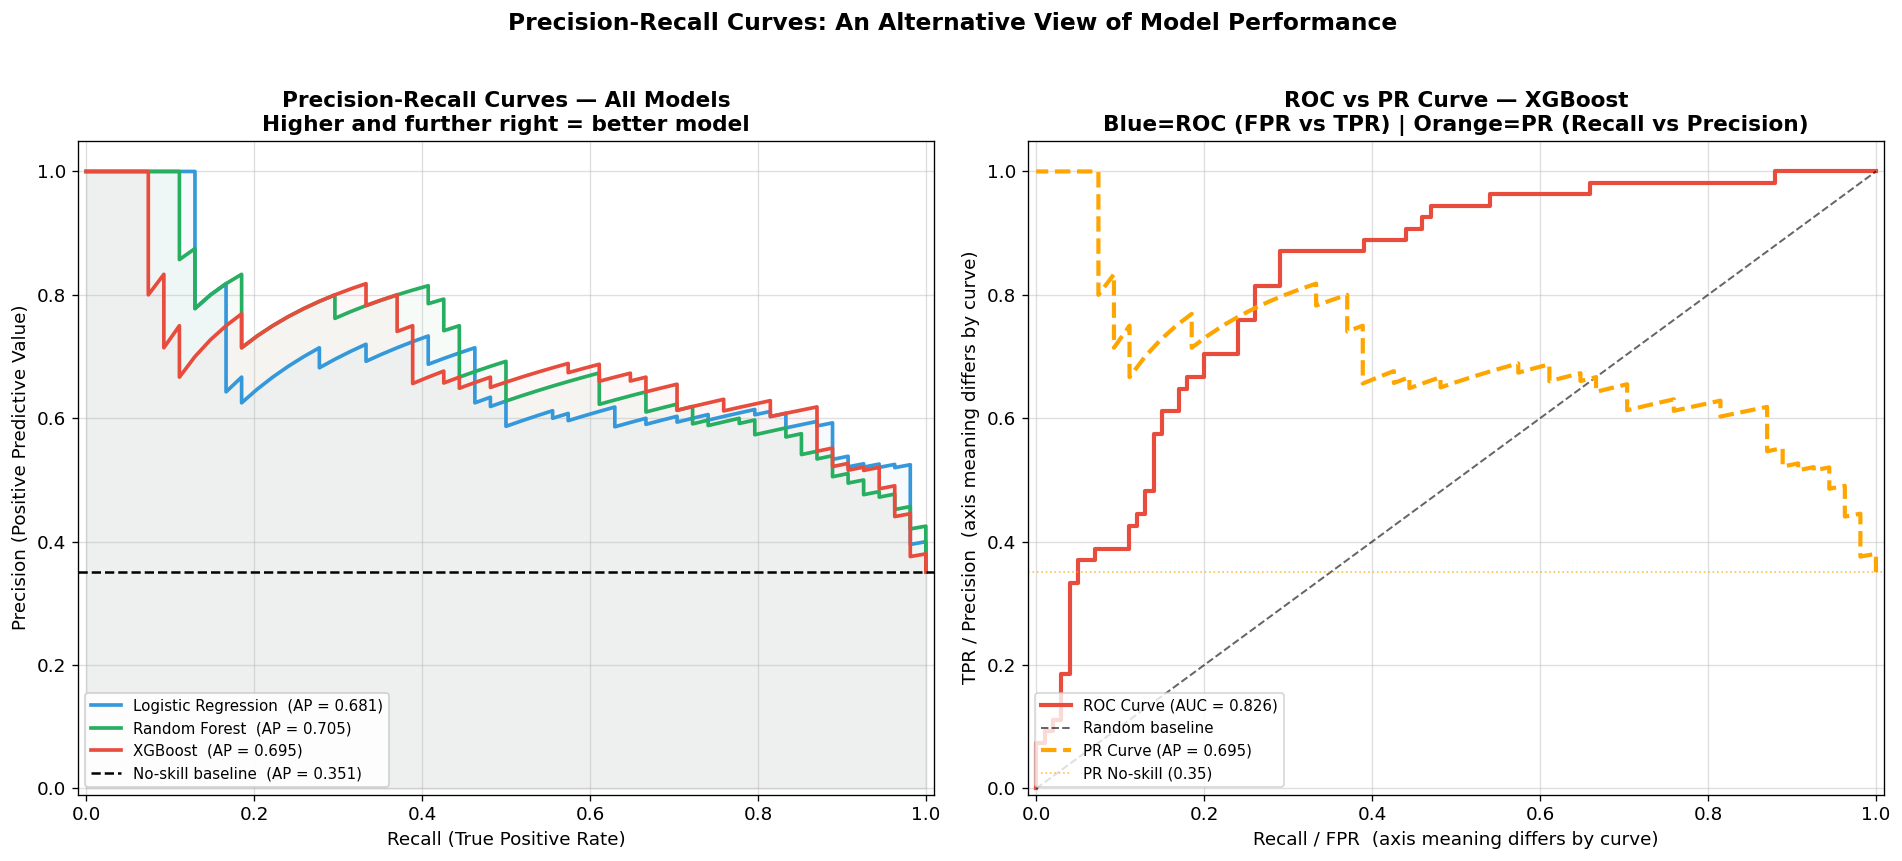


AP (Average Precision) interpretation:
  AP = weighted average of Precision across all Recall levels.
  It is the area under the PR curve (like AUC is for ROC).
  No-skill baseline AP = 0.351 (= positive class proportion)
  Any useful model should achieve AP substantially above this baseline.


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Precision-Recall curves for all models
#       Also side-by-side comparison: ROC vs PR for the same model
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: PR curves for all models
ax = axes[0]
pr_model_data = [
    ("Logistic Regression", y_prob_lr,  "#3498db"),
    ("Random Forest",       y_prob_rf,  "#27ae60"),
    (model_name,            y_prob_xgb, "#e74c3c"),
]

# Baseline: a "no-skill" classifier predicts the positive class with probability = base rate
baseline_precision = y_test.mean()

for name, probs, color in pr_model_data:
    precision_arr, recall_arr, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    ax.plot(recall_arr, precision_arr, color=color, lw=2.2,
            label=f"{name}  (AP = {ap:.3f})")
    ax.fill_between(recall_arr, precision_arr, alpha=0.04, color=color)

# No-skill baseline (horizontal line at positive class prevalence)
ax.axhline(baseline_precision, color="black", linestyle="--", lw=1.5,
           label=f"No-skill baseline  (AP = {baseline_precision:.3f})")

ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
ax.set_xlabel("Recall (True Positive Rate)")
ax.set_ylabel("Precision (Positive Predictive Value)")
ax.set_title("Precision-Recall Curves — All Models\n"
             "Higher and further right = better model", fontweight="bold")
ax.legend(loc="lower left", fontsize=9, framealpha=0.9)

# ── Right: ROC vs PR for best model side-by-side
best_model_idx = np.argmax([roc_auc_score(y_test, probs) for _, probs, _ in pr_model_data])
best_name, best_probs, best_color = pr_model_data[best_model_idx]

ax2 = axes[1]
# Mini ROC
fpr_b, tpr_b, _ = roc_curve(y_test, best_probs)
auc_b = auc(fpr_b, tpr_b)
ax2.plot(fpr_b, tpr_b, color=best_color, lw=2.5,
         label=f"ROC Curve (AUC = {auc_b:.3f})")
ax2.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.6, label="Random baseline")

# Overlay PR curve on same axes (note: different axis meanings!)
prec_b, rec_b, _ = precision_recall_curve(y_test, best_probs)
ap_b = average_precision_score(y_test, best_probs)
ax2.plot(rec_b, prec_b, color="orange", lw=2.5, linestyle="--",
         label=f"PR Curve (AP = {ap_b:.3f})")
ax2.axhline(baseline_precision, color="orange", lw=1.0, linestyle=":",
            alpha=0.7, label=f"PR No-skill ({baseline_precision:.2f})")

ax2.set_xlim([-0.01, 1.01])
ax2.set_ylim([-0.01, 1.05])
ax2.set_xlabel("Recall / FPR  (axis meaning differs by curve)")
ax2.set_ylabel("TPR / Precision  (axis meaning differs by curve)")
ax2.set_title(f"ROC vs PR Curve — {best_name}\n"
              "Blue=ROC (FPR vs TPR) | Orange=PR (Recall vs Precision)", fontweight="bold")
ax2.legend(loc="lower left", fontsize=9)

plt.suptitle(
    "Precision-Recall Curves: An Alternative View of Model Performance",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

print("\nAP (Average Precision) interpretation:")
print("  AP = weighted average of Precision across all Recall levels.")
print("  It is the area under the PR curve (like AUC is for ROC).")
print(f"  No-skill baseline AP = {baseline_precision:.3f} (= positive class proportion)")
print("  Any useful model should achieve AP substantially above this baseline.")

---
## Part 13: When ROC/AUC Can Be Misleading

### Known Limitations of AUC

AUC is an excellent general-purpose metric, but it has important failure modes:

#### 1. Severe Class Imbalance
As discussed above, ROC-AUC can remain high even when a model performs poorly
on the minority class. For fraud detection (0.1% fraud rate), an AUC of 0.95
can still mean thousands of missed frauds. Use PR-AUC or F1 in these cases.

#### 2. AUC Aggregates Across All Thresholds — Including Irrelevant Ones
If you know your application will only ever operate at a low FPR (e.g., FPR < 0.2),
then the AUC at high FPR values is irrelevant. Consider using:
- **Partial AUC** (area under the ROC curve up to a specific FPR limit)
- **AUPRC** (PR-AUC)

#### 3. AUC Doesn't Tell You About Calibration
A model with AUC = 0.85 perfectly ranks patients, but the probabilities themselves
might be wrong (e.g., all between 0.4 and 0.6 — not 0 and 1). For tasks where
probability values matter (expected value calculations, risk scores), use calibration
plots (`CalibrationDisplay`) and Brier score.

#### 4. Comparing AUC Across Different Datasets Is Misleading
AUC = 0.85 on a balanced dataset is not the same as AUC = 0.85 on a highly
imbalanced dataset. Always report dataset composition alongside AUC scores.

#### 5. Multi-Class Problems
AUC in multi-class settings requires careful interpretation:
- `roc_auc_score(..., multi_class='ovr')` — One-vs-Rest (OvR)
- `roc_auc_score(..., multi_class='ovo')` — One-vs-One (OvO)
Results differ significantly depending on the strategy chosen.

Demonstrating: ROC vs PR under severe class imbalance

Original test set:  154 samples,  35.1% positive
Imbalanced version: 105 samples, 4.8% positive

Metric                           Original (35% pos)    Imbalanced (5% pos)
---------------------------------------------------------------------------
  ROC-AUC                                     0.817                  0.900
  PR-AUC (Avg Precision)                      0.681                  0.542


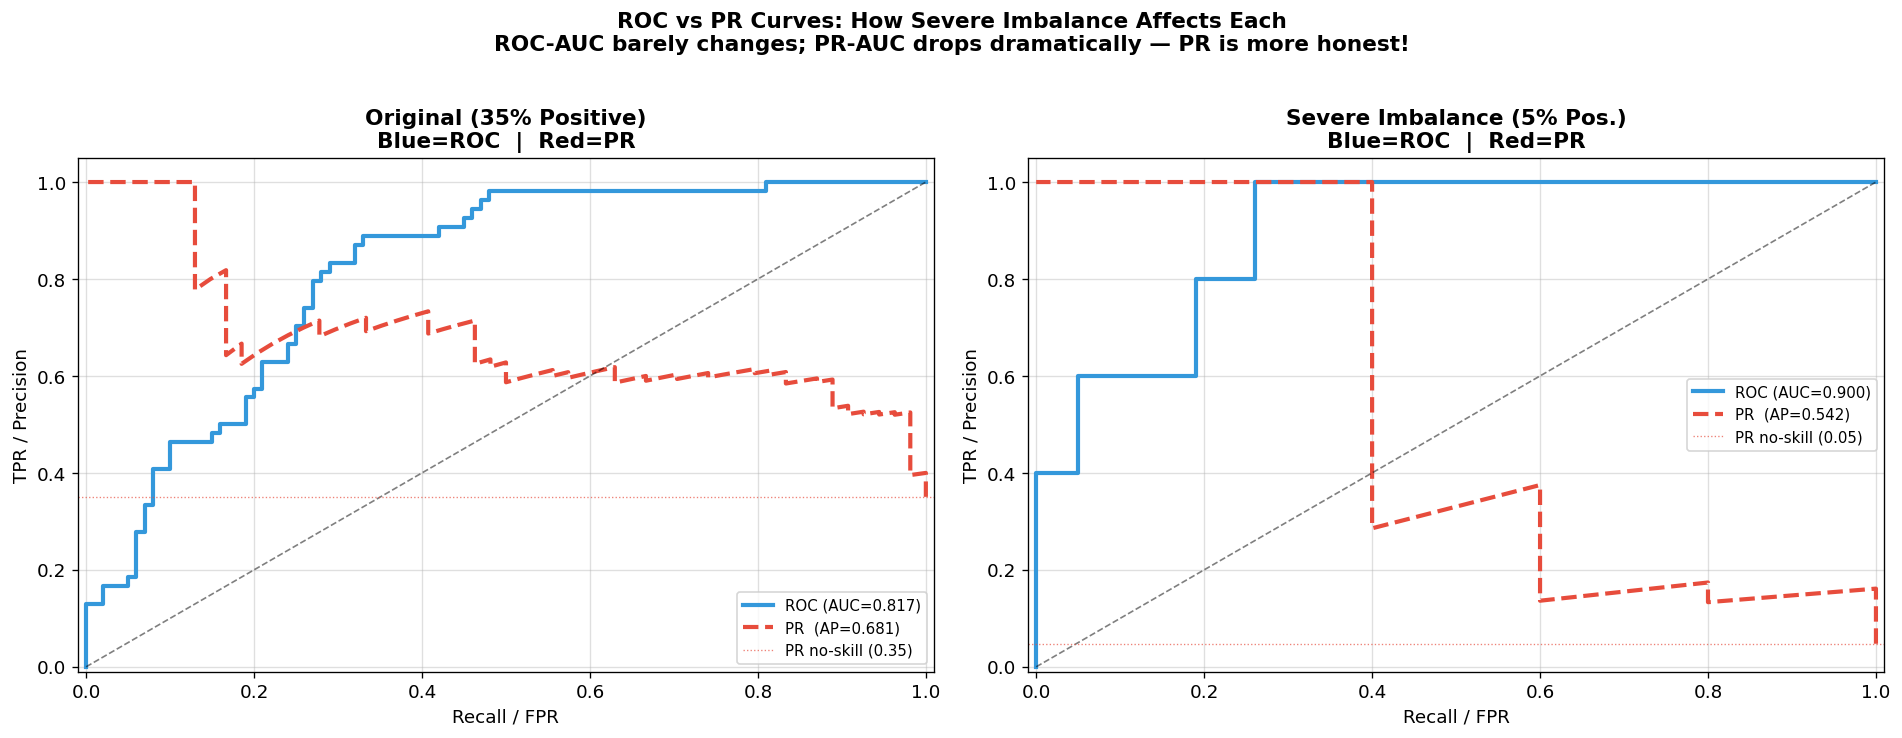


Conclusion:
  ROC-AUC barely changes: 0.817 → 0.900
  PR-AUC drops sharply:   0.681 → 0.542

  Under severe imbalance, PR-AUC is more informative about whether
  the model can actually find the rare positive cases.


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Demonstrate the imbalance problem — ROC looks fine, PR reveals the issue
#
# We simulate a SEVERELY imbalanced version of our dataset (5% positive class)
# and show that ROC-AUC remains high while PR-AUC is much more revealing.
# ─────────────────────────────────────────────────────────────────────────────

print("Demonstrating: ROC vs PR under severe class imbalance")
print("=" * 65)

# ── Create a severely imbalanced version (5% positive class)
# Take all 35% positives from test set and subsample to ~5%
pos_indices  = np.where(y_test.values == 1)[0]
neg_indices  = np.where(y_test.values == 0)[0]

# Keep all negatives, subsample positives to 5% of total
target_pos = max(5, int(0.05 * len(neg_indices)))
rng_imb = np.random.default_rng(RANDOM_STATE)
sampled_pos = rng_imb.choice(pos_indices, size=min(target_pos, len(pos_indices)), replace=False)
all_indices_imb = np.concatenate([neg_indices, sampled_pos])

y_test_imb  = y_test.values[all_indices_imb]
y_prob_imb  = y_prob_lr[all_indices_imb]

print(f"\nOriginal test set:  {len(y_test)} samples,  {y_test.mean()*100:.1f}% positive")
print(f"Imbalanced version: {len(y_test_imb)} samples, {y_test_imb.mean()*100:.1f}% positive")

# ── Compute metrics for both
roc_auc_orig = roc_auc_score(y_test,     y_prob_lr)
roc_auc_imb  = roc_auc_score(y_test_imb, y_prob_imb)
pr_auc_orig  = average_precision_score(y_test,     y_prob_lr)
pr_auc_imb   = average_precision_score(y_test_imb, y_prob_imb)

print(f"\n{'Metric':<30} {'Original (35% pos)':>20} {'Imbalanced (5% pos)':>22}")
print("-" * 75)
print(f"  {'ROC-AUC':<28} {roc_auc_orig:>20.3f} {roc_auc_imb:>22.3f}")
print(f"  {'PR-AUC (Avg Precision)':<28} {pr_auc_orig:>20.3f} {pr_auc_imb:>22.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
datasets = [
    ("Original (35% Positive)",     y_test.values,  y_prob_lr,  "Original"),
    ("Severe Imbalance (5% Pos.)",  y_test_imb,     y_prob_imb, "Imbalanced"),
]

for ax, (title_str, y_t, y_p, suffix) in zip(axes, datasets):
    fpr_t, tpr_t, _ = roc_curve(y_t, y_p)
    prec_t, rec_t, _ = precision_recall_curve(y_t, y_p)
    roc_val = auc(fpr_t, tpr_t)
    ap_val  = average_precision_score(y_t, y_p)
    base_pr = y_t.mean()
    
    ax.plot(fpr_t, tpr_t, color="#3498db", lw=2.5, label=f"ROC (AUC={roc_val:.3f})")
    ax.plot(rec_t, prec_t, color="#e74c3c", lw=2.5, linestyle="--",
            label=f"PR  (AP={ap_val:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax.axhline(base_pr, color="#e74c3c", lw=0.8, linestyle=":", alpha=0.7,
               label=f"PR no-skill ({base_pr:.2f})")
    
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.05])
    ax.set_title(f"{title_str}\nBlue=ROC  |  Red=PR", fontweight="bold")
    ax.set_xlabel("Recall / FPR")
    ax.set_ylabel("TPR / Precision")
    ax.legend(fontsize=9)

plt.suptitle(
    "ROC vs PR Curves: How Severe Imbalance Affects Each\n"
    "ROC-AUC barely changes; PR-AUC drops dramatically — PR is more honest!",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

print("\nConclusion:")
print(f"  ROC-AUC barely changes: {roc_auc_orig:.3f} → {roc_auc_imb:.3f}")
print(f"  PR-AUC drops sharply:   {pr_auc_orig:.3f} → {pr_auc_imb:.3f}")
print("\n  Under severe imbalance, PR-AUC is more informative about whether")
print("  the model can actually find the rare positive cases.")

---
## Part 14: Summary and Key Takeaways

### Everything You Learned in This Notebook

---

#### The Core Formula Chain

$$\text{TP} + \text{TN} + \text{FP} + \text{FN} = \text{Total Samples}$$

$$\text{TPR} = \frac{TP}{TP + FN} \qquad \text{FPR} = \frac{FP}{FP + TN} \qquad \text{Specificity} = 1 - \text{FPR}$$

$$\text{ROC Curve} = \text{plot of TPR vs FPR for all thresholds} \qquad \text{AUC} = \int_0^1 \text{TPR} \, d(\text{FPR})$$

---

#### 10 Essential Facts About ROC Curves and AUC

1. **ROC curves show ALL possible threshold choices at once** — moving left-to-right on the curve corresponds to raising the threshold.

2. **The diagonal line represents a random classifier** (AUC = 0.5). Any useful model must be above it.

3. **AUC is the probability that a random positive is ranked above a random negative** by the model's score.

4. **AUC = 1.0 is perfect; AUC = 0.5 is useless; AUC < 0.5 means labels may be inverted.**

5. **Accuracy can be 90% while TPR is 0** — this happens with imbalanced data and a biased classifier.

6. **Lowering the threshold increases TPR AND FPR** (more positives predicted → catch more real ones, but also more false alarms).

7. **The Youden's J statistic** (TPR − FPR) is a common way to automatically select the optimal threshold when FP and FN costs are equal.

8. **AUC is threshold-independent** — it summarises the model's ranking ability regardless of any specific cutoff choice.

9. **ROC-AUC can be misleading under severe class imbalance** — use PR-AUC (Average Precision) in those cases.

10. **ROC curves don't measure probability calibration** — a model can have high AUC but wildly wrong probability estimates.

---

#### When to Use Which Metric

| Metric | Best For |
|--------|----------|
| **AUC-ROC** | General model comparison, balanced/mild imbalance, ranking ability |
| **PR-AUC (AP)** | Severe class imbalance, when false positives are very costly |
| **F1 Score** | Single-number summary that balances Precision and Recall |
| **Recall (TPR)** | Safety-critical screening (minimise missed cases) |
| **Precision** | When false alarms are costly (spam filter, recommendation) |
| **Accuracy** | Balanced datasets only — misleading otherwise |
| **Youden's J** | Automated threshold selection (equal FP/FN costs) |

---

#### Next Steps

- **Calibrate your probabilities:** use `CalibratedClassifierCV` or `IsotonicRegression`
- **Handle imbalanced data:** try `class_weight='balanced'`, SMOTE, or cost-sensitive learning
- **Cross-validate AUC:** use `cross_val_score(..., scoring='roc_auc')` for a more reliable estimate
- **Bootstrap confidence intervals:** AUC point estimates are noisy on small test sets
- **Explore partial AUC:** `roc_auc_score(..., max_fpr=0.2)` for operating-range-specific evaluation

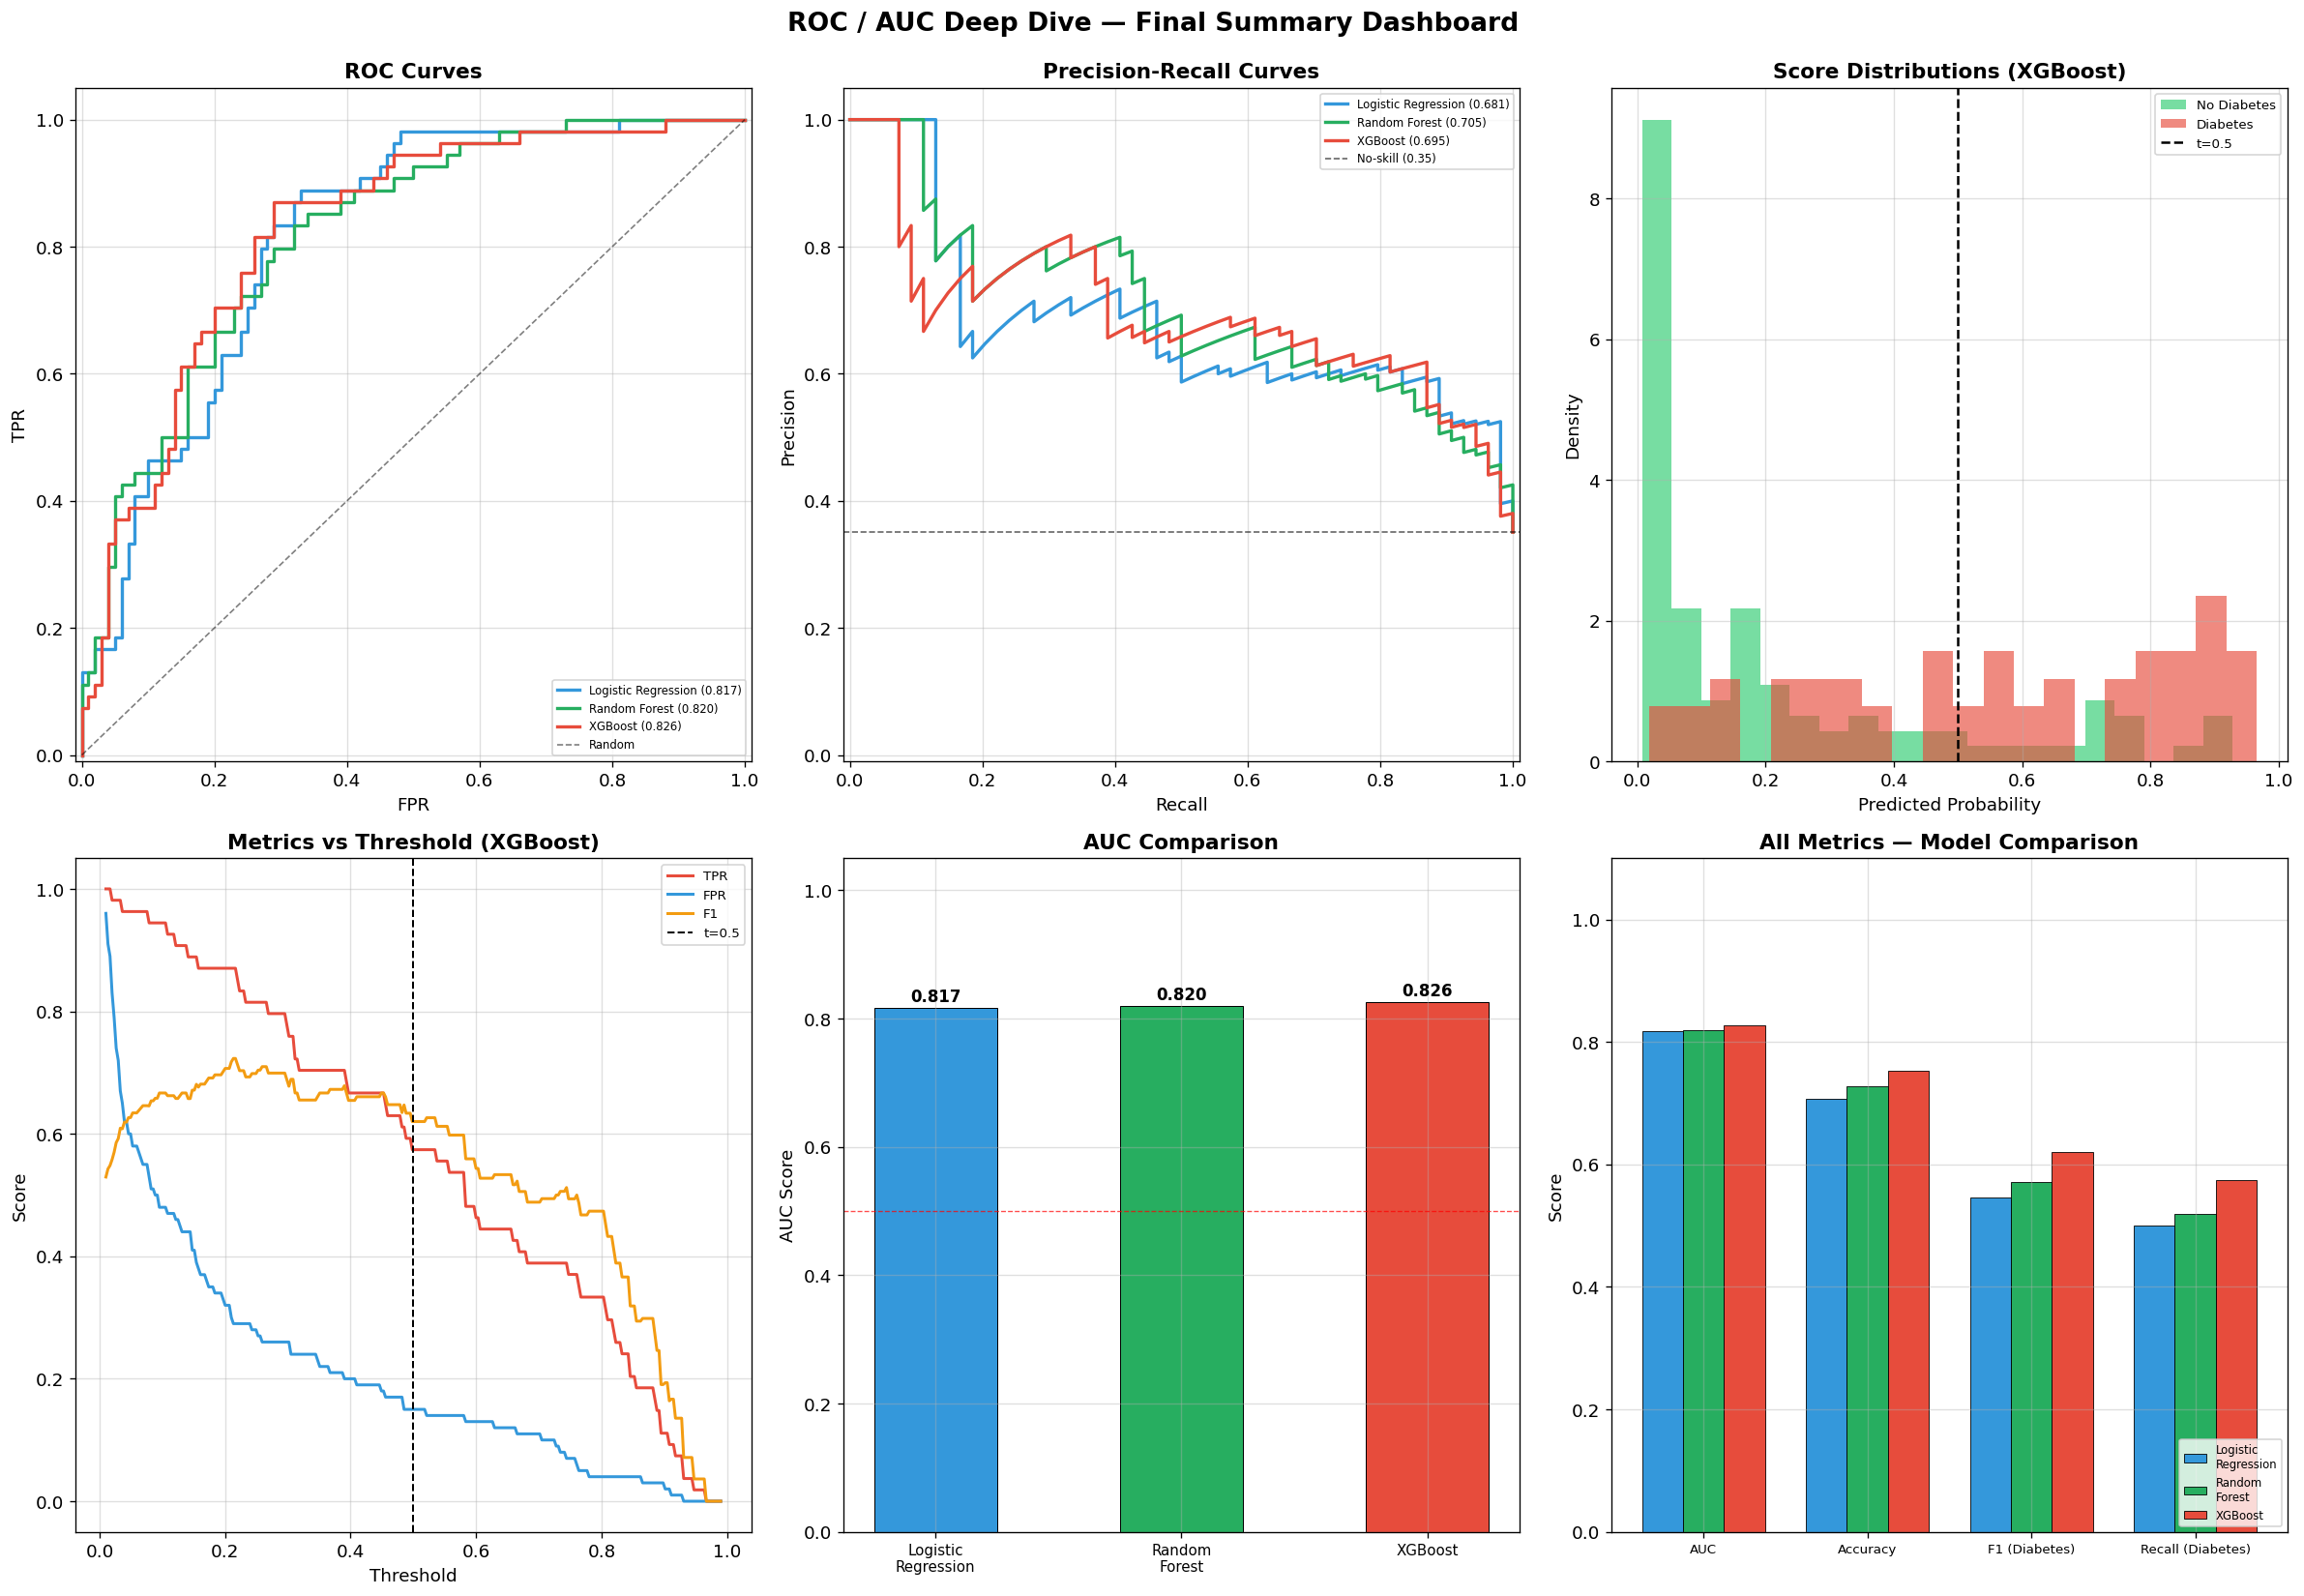


✓ Summary dashboard saved as 'roc_auc_summary_dashboard.png'

Notebook complete! You now have a deep working knowledge of:
  • TPR, FPR, Specificity, Precision, Recall, F1, Accuracy
  • Classification thresholds and their effect on every metric
  • How to build, read, and interpret ROC curves
  • How to calculate and compare AUC scores across models
  • How to tune thresholds for clinical or business goals
  • When ROC/AUC can mislead you (imbalance, calibration)
  • Precision-Recall curves as a complement to ROC


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Final summary dashboard — one figure that summarises the whole notebook
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(20, 14))

# ── Title
fig.text(0.5, 0.98,
         "ROC / AUC Deep Dive — Final Summary Dashboard",
         ha="center", va="top", fontsize=16, fontweight="bold")

# ── Grid layout: 2 rows × 3 columns
ax1 = fig.add_subplot(2, 3, 1)   # ROC all models
ax2 = fig.add_subplot(2, 3, 2)   # PR all models
ax3 = fig.add_subplot(2, 3, 3)   # Probability distributions (best model)
ax4 = fig.add_subplot(2, 3, 4)   # Threshold vs TPR/FPR (best model)
ax5 = fig.add_subplot(2, 3, 5)   # AUC comparison bar chart
ax6 = fig.add_subplot(2, 3, 6)   # Metrics comparison bar chart

palette_m = ["#3498db", "#27ae60", "#e74c3c"]

# ── Ax1: ROC all models
for (name, fpr_m, tpr_m, auc_m, color) in model_roc_data:
    ax1.plot(fpr_m, tpr_m, color=color, lw=2, label=f"{name} ({auc_m:.3f})")
ax1.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random")
ax1.set_xlim([-0.01, 1.01]); ax1.set_ylim([-0.01, 1.05])
ax1.set_xlabel("FPR"); ax1.set_ylabel("TPR")
ax1.set_title("ROC Curves", fontweight="bold")
ax1.legend(fontsize=7, loc="lower right")

# ── Ax2: PR all models
for name, probs, color in pr_model_data:
    prec_a, rec_a, _ = precision_recall_curve(y_test, probs)
    ap_a = average_precision_score(y_test, probs)
    ax2.plot(rec_a, prec_a, color=color, lw=2, label=f"{name} ({ap_a:.3f})")
ax2.axhline(y_test.mean(), color="black", lw=1, linestyle="--",
            alpha=0.6, label=f"No-skill ({y_test.mean():.2f})")
ax2.set_xlim([-0.01, 1.01]); ax2.set_ylim([-0.01, 1.05])
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curves", fontweight="bold")
ax2.legend(fontsize=7, loc="upper right")

# ── Ax3: Probability histograms for best model
best_prob = best_probs
ax3.hist(best_prob[y_test == 0], bins=20, alpha=0.65, color="#2ecc71",
         label="No Diabetes", density=True)
ax3.hist(best_prob[y_test == 1], bins=20, alpha=0.65, color="#e74c3c",
         label="Diabetes", density=True)
ax3.axvline(0.5, color="black", lw=1.5, linestyle="--", label="t=0.5")
ax3.set_xlabel("Predicted Probability"); ax3.set_ylabel("Density")
ax3.set_title(f"Score Distributions ({best_name})", fontweight="bold")
ax3.legend(fontsize=8)

# ── Ax4: Threshold sweep for best model (on test set)
best_prob_test = best_probs
th_sweep = np.linspace(0.01, 0.99, 300)
tpr_s, fpr_s, f1_s = [], [], []
for t in th_sweep:
    y_pt = (best_prob_test >= t).astype(int)
    tpr_v = recall_score(y_test, y_pt, zero_division=0)
    fp_v  = ((y_pt==1)&(y_test==0)).sum()
    tn_v  = ((y_pt==0)&(y_test==0)).sum()
    fpr_v = fp_v / (fp_v + tn_v) if (fp_v + tn_v) > 0 else 0
    f1_v  = f1_score(y_test, y_pt, zero_division=0)
    tpr_s.append(tpr_v); fpr_s.append(fpr_v); f1_s.append(f1_v)

ax4.plot(th_sweep, tpr_s, color="#e74c3c", lw=1.8, label="TPR")
ax4.plot(th_sweep, fpr_s, color="#3498db", lw=1.8, label="FPR")
ax4.plot(th_sweep, f1_s,  color="#f39c12", lw=1.8, label="F1")
ax4.axvline(0.5, color="black", lw=1.2, linestyle="--", label="t=0.5")
ax4.set_xlabel("Threshold"); ax4.set_ylabel("Score")
ax4.set_title(f"Metrics vs Threshold ({best_name})", fontweight="bold")
ax4.legend(fontsize=8)

# ── Ax5: AUC bar chart
names_m = [d[0] for d in model_roc_data]
aucs_m  = [d[3] for d in model_roc_data]
bars = ax5.bar(range(3), aucs_m, color=palette_m, edgecolor="black", lw=0.6, width=0.5)
ax5.set_xticks(range(3))
ax5.set_xticklabels([n.replace(" ", "\n") for n in names_m], fontsize=9)
ax5.set_ylim([0, 1.05]); ax5.set_ylabel("AUC Score")
ax5.set_title("AUC Comparison", fontweight="bold")
ax5.axhline(0.5, color="red", lw=0.8, linestyle="--", alpha=0.7)
for bar, v in zip(bars, aucs_m):
    ax5.text(bar.get_x()+bar.get_width()/2, v+0.01, f"{v:.3f}",
             ha="center", fontweight="bold", fontsize=10)

# ── Ax6: Multi-metric comparison
metrics_names_plot = ["AUC", "Accuracy", "F1 (Diabetes)", "Recall (Diabetes)"]
x_pos = np.arange(len(metrics_names_plot))
width = 0.25
model_keys = list(metrics_summary.keys())
for i, (mk, color) in enumerate(zip(model_keys, palette_m)):
    vals = [metrics_summary[mk].get(m, 0) for m in metrics_names_plot]
    ax6.bar(x_pos + i*width, vals, width, label=mk.replace(" ","\n"),
            color=color, edgecolor="black", lw=0.5)
ax6.set_xticks(x_pos + width)
ax6.set_xticklabels(metrics_names_plot, fontsize=8)
ax6.set_ylim([0, 1.1]); ax6.set_ylabel("Score")
ax6.set_title("All Metrics — Model Comparison", fontweight="bold")
ax6.legend(fontsize=7, loc="lower right")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("roc_auc_summary_dashboard.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

print("\n✓ Summary dashboard saved as 'roc_auc_summary_dashboard.png'")
print("\nNotebook complete! You now have a deep working knowledge of:")
print("  • TPR, FPR, Specificity, Precision, Recall, F1, Accuracy")
print("  • Classification thresholds and their effect on every metric")
print("  • How to build, read, and interpret ROC curves")
print("  • How to calculate and compare AUC scores across models")
print("  • How to tune thresholds for clinical or business goals")
print("  • When ROC/AUC can mislead you (imbalance, calibration)")
print("  • Precision-Recall curves as a complement to ROC")